**Chapter 9 – Unsupervised Learning**
This chapter covers unsupervised learning techniques, where the goal is to find hidden patterns in data without labeled examples. We'll start with clustering, a key unsupervised task, and explore algorithms like K-Means to group similar instances. By the end, you'll understand how to apply these methods to real-world datasets, evaluate their performance, and choose the right number of clusters. Let's dive in!

_This notebook contains all the sample code and solutions to the exercises in chapter 9._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/unsupervised_learning` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures.

---
# Clustering

**Introduction – Classification _vs_ Clustering**

In classification, we have labeled data and we want to learn a mapping from inputs to labels. 

In clustering, we have unlabeled data and we want to group similar instances together based on their features.

To illustrate the difference between classification and clustering, let's visualize the iris dataset. 

In classification, we use labeled data to train a model, while in clustering, we group similar instances without labels. 

The following code generates a plot showing the labeled classes on the left and the unlabeled data points on the right.
The Iris dataset, introduced by Ronald Fisher in 1936, is a foundational dataset in machine learning for classification and clustering tasks. It consists of 150 samples of iris flowers, each described by four numerical features: sepal length, sepal width, petal length, and petal width (all in centimeters). The samples are evenly distributed across three species: *Iris setosa*, *Iris versicolor*, and *Iris virginica*, with 50 instances per class. This dataset is ideal for demonstrating supervised learning (classification) using the labeled species and unsupervised learning (clustering) by grouping similar flowers based on features alone. In the context of this chapter, we'll use it to highlight the differences between these approaches.

In [ ]:
# extra code – this cell generates and saves Figure 9–1

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target
print("three species:", data.target_names)
print("feature names:", data.feature_names)

plt.figure(figsize=(9, 3.5))

plt.subplot(121)
# use feature 2 and 3 (petal length and petal width)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa") # select instances of class 0
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor") # select instances of class 1
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica") # select instances of class 2
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".") # plot all instances without labels
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()

save_fig("classification_vs_clustering_plot")
plt.show()

**Note**: the next cell shows how a **Gaussian mixture model** (explained later in this chapter) can actually separate these clusters pretty well using all 4 features: petal length & width, and sepal length & width. This code maps each cluster to a class. Instead of hard coding the mapping, the code picks the most common class for each cluster using the `scipy.stats.mode()` function:

In [ ]:
# extra code

import numpy as np
from scipy import stats # statistics functions
from sklearn.mixture import GaussianMixture # Gaussian Mixture Model (GMM)

y_pred_gmm = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X) # predict cluster labels
print(f"list cluster labels and target classes:\n{y_pred_gmm}\n{y}")

# map each cluster to a class
mapping = {}
for class_id in np.unique(y):
    mode, _ = stats.mode(y_pred_gmm[y==class_id])
    mapping[mode] = class_id
print(f"cluster mapping:\n{mapping}")

# create predicted class labels based on cluster assignments
y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred_gmm])

plt.plot(X[y_pred==0, 2], X[y_pred==0, 3], "yo", label="Cluster 1")
plt.plot(X[y_pred==1, 2], X[y_pred==1, 3], "bs", label="Cluster 2")
plt.plot(X[y_pred==2, 2], X[y_pred==2, 3], "g^", label="Cluster 3")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.grid()
plt.show()

What's the ratio of iris plants we assigned to the right cluster?

In [ ]:
(y_pred==y).sum() / len(y_pred)

### GMM clustering → map clusters to true labels

- Purpose: fit a GaussianMixture (soft clustering), obtain hard labels, and map cluster IDs to original class IDs for evaluation/visualization.

- Workflow
    - Imports: numpy, scipy.stats, GaussianMixture.
    - Fit & predict (hard labels):
        - `y_pred_gmm = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)`
            - `n_components=3` for 3 clusters (iris species).
    - Build mapping (majority vote per target class):
        - For each target class id in `np.unique(y)`, compute the most frequent predicted cluster among its samples:
            - `mode, _ = stats.mode(y_pred_gmm[y==class_id])`: get most common cluster for samples of `class_id`.
            - `mapping[mode] = class_id`: store mapping from cluster to class.
        - Remap: `y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred_gmm])`
            - Create new array where each predicted cluster ID is replaced by its mapped class ID.

- Notes & gotchas
    - `stats.mode` returns a ModeResult object.
    - Multiple true classes can map to the same cluster (or some clusters remain unmapped). For a robust one-to-one mapping, use the confusion matrix + Hungarian algorithm:
        - `cm = confusion_matrix(y, y_pred)`: compute confusion matrix.
        - `row_ind, col_ind = linear_sum_assignment(-cm)`: maximize matches.
        - `mapping = {col: row for row, col in zip(row_ind, col_ind)}`: build one-to-one mapping.
    - GMM is soft: you can use `predict_proba()` (responsibilities) and assign labels with `argmax` if preferred.

In [ ]:
# more robust: use confusion matrix + Hungarian algorithm for one-to-one mapping
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

cm = confusion_matrix(y, y_pred_gmm)
row_ind, col_ind = linear_sum_assignment(-cm)  # maximize matches
mapping = {col: row for row, col in zip(row_ind, col_ind)}
y_pred_cm = np.array([mapping[c] for c in y_pred_gmm])

In [ ]:
# Compare y_pred_cm to y_pred
print("Accuracy Ratio:", (y_pred_cm == y).sum() / len(y_pred_cm))
print(np.all(y_pred_cm == y_pred))

In [ ]:
cm
print(cm)
print(row_ind, col_ind)
print(mapping)

---
## K-Means
K-Means is a popular clustering algorithm that partitions data into k clusters by *minimizing the inertia (sum of squared distances from each point to its assigned centroid)*. It iteratively assigns points to the nearest centroid and updates centroids to the mean of their assigned points. Scikit-Learn's `KMeans` class supports initialization methods like K-Means++ (default) for better convergence, multiple runs via `n_init` to avoid local minima, and variants like Mini-Batch K-Means for large datasets. Key hyperparameters include `n_clusters` (k), `init`, `n_init`, and `max_iter`. Inertia serves as an evaluation metric, though it's not perfect for choosing k—methods like the elbow rule or silhouette analysis are often used. The algorithm is efficient but assumes spherical clusters and can be sensitive to initialization.

**Fit and predict**

Let's train a K-Means clusterer on a dataset of blobs. It will try to find each blob's center and assign each instance to the closest blob:

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

# extra code – the exact arguments of make_blobs() are not important
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]]) # coordinates of blob centers
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1]) # standard deviations of blobs
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,
                  random_state=7)

k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

Note: Throughout this notebook, when `n_init` was not set when creating a `KMeans` estimator, I explicitly set it to `n_init=10` to avoid a warning about the fact that the default value for this hyperparameter will change from 10 to `"auto"` in Scikit-Learn 1.4.

Now let's plot them:

In [ ]:
# extra code – this cell generates and saves Figure 9–2
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    """Plot the instances in X, coloring them according to y if provided."""
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1, label="instances")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.scatter(blob_centers[:, 0], blob_centers[:, 1], c="red", marker="x", s=50, linewidths=3, label="centers")
plt.legend(loc="best")
plt.gca().set_axisbelow(True)
plt.grid()
save_fig("blobs_plot")
plt.show()

Each instance was assigned to one of the 5 clusters:

In [ ]:
y_pred

In [ ]:
y_pred is kmeans.labels_

This cell verifies that `y_pred` (the array of cluster labels returned by `fit_predict()`) is the same object as `kmeans.labels_` (the labels attribute of the fitted KMeans model). It returns `True`, confirming that both reference the same array in memory, as `fit_predict()` internally sets `labels_` and returns it. This is a way to check object identity rather than value equality.

And the following 5 _centroids_ (i.e., cluster centers) were estimated:

In [ ]:
kmeans.cluster_centers_

In [ ]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.scatter(blob_centers[:, 0], blob_centers[:, 1], c="red", marker="x", s=75, linewidths=3, label="true centers", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c="blue", marker="o", s=50, linewidths=1, label="kmeans centers")
plt.legend()
plt.show()

Note that the `KMeans` instance preserves the labels of the instances it was trained on. Somewhat confusingly, in this context, the _label_ of an instance is the *index of the cluster* that instance gets assigned to (they are not targets, they are predictions):

In [ ]:
kmeans.labels_

Of course, we can predict the labels of new instances:

In [ ]:
import numpy as np

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

**Decision Boundaries**

Let's plot the model's decision boundaries. This gives us a _Voronoi diagram_:

In [54]:
# extra code – this cell generates and saves Figure 9–3

def plot_data(X):
    """Plot the data points in X as black dots."""
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    """Plot the centroids as circles and crosses.
        Args:
            centroids: A 2D numpy array containing the coordinates of the centroids.
            weights: Optional; a 1D numpy array containing the weights of the centroids.
            circle_color: Color of the circles.
            cross_color: Color of the crosses.
    """
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)
    for i, centroid in enumerate(centroids):
        plt.text(centroid[0]+0.1, centroid[1]+0.1, i,
                 fontsize=12, fontweight='bold',
                 color='red', zorder=12,
                 horizontalalignment='center',
                 verticalalignment='center')

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    """Plot the decision boundaries of a clusterer over the data X.
        Args:
            clusterer: A clustering model with a predict() method and cluster_centers_ attribute.
            X: The input data, a 2D numpy array.
            resolution: The resolution of the grid used to plot the decision boundaries.
            show_centroids: Whether to plot the centroids of the clusters.
            show_xlabels: Whether to show x-axis labels.
            show_ylabels: Whether to show y-axis labels.
    """
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)


In [ ]:

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
save_fig("voronoi_plot")
plt.show()

Not bad! Some of the instances near the edges were probably assigned to the wrong cluster, but overall it looks pretty good.

**Hard Clustering _vs_ Soft Clustering**

Rather than arbitrarily choosing the closest cluster for each instance, which is called _hard clustering_, it might be better to *measure the distance of each instance to all 5 centroids*. This is what the `transform()` method does:

In [ ]:
kmeans.transform(X_new).round(2)

You can verify that this is indeed the Euclidian distance between each instance and each centroid:

In [ ]:
# extra code
np.linalg.norm(np.tile(X_new, (1, k)).reshape(-1, k, 2)
               - kmeans.cluster_centers_, axis=2).round(2)

In [ ]:
plt.figure(figsize=(8, 4))
plot_data(X)
plot_centroids(kmeans.cluster_centers_)
plt.scatter(X_new[:, 0], X_new[:, 1], c="red", marker="*", s=150, label="new instances")
plt.legend(loc="upper right")
save_fig("kmeans_new_instances_plot")
plt.show()

---
### The K-Means Algorithm

The K-Means algorithm is one of the fastest clustering algorithms, and also one of the simplest:
* First initialize $k$ centroids randomly: e.g., $k$ distinct instances are chosen randomly from the dataset and the centroids are placed at their locations.
* Repeat until convergence (i.e., until the centroids stop moving):
    * Assign each instance to the closest centroid.
    * **Update the centroids to be the mean of the instances that are assigned to them.**

The `KMeans` class uses an optimized initialization technique by default. To get the original K-Means algorithm (for educational purposes only), you must set `init="random"` and `n_init=1`. More on this later in this chapter.

Let's run the K-Means algorithm for 1, 2 and 3 iterations, to see how the centroids move around:

In [ ]:
# extra code – this cell generates and saves Figure 9–4

kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=1,
                      random_state=5)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=2,
                      random_state=5)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=3,
                      random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)")

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False,
                         show_ylabels=False)
plt.title("Label the instances")

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False,
                         show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False,
                         show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

save_fig("kmeans_algorithm_plot")
plt.show()

**K-Means Variability**

In the original K-Means algorithm, the centroids are just initialized randomly, and the algorithm simply runs a single iteration to gradually improve the centroids, as we saw above.

However, one major problem with this approach is that if you run K-Means multiple times (or with different random seeds), it can converge to very different solutions, as you can see below:

In [ ]:
# extra code – this cell generates and saves Figure 9–5

def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None,
                              title2=None):
    """Plot side-by-side decision boundaries of two clusterers on the same data.
        Args:
            clusterer1: The first clustering model.
            clusterer2: The second clustering model.
            X: The input data, a 2D numpy array.
            title1: Optional; title for the first subplot.
            title2: Optional; title for the second subplot."""
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2)

# Create two KMeans clusterers with different random initializations
kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1, random_state=2)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=1, random_state=9)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1",
                          "Solution 2 (with a different random init)")

save_fig("kmeans_variability_plot")
plt.show()

`good_init` is a NumPy array defining custom initial centroids for the K-Means algorithm. It provides 5 starting points (one per cluster) based on prior knowledge of the blob centers, ensuring better convergence than random initialization. In the code, it's passed to `KMeans` via the `init` parameter, with `n_init=1` to use these exact initials without multiple runs. This approach minimizes inertia and avoids suboptimal solutions, as demonstrated in the subsequent plot.

In [ ]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]]) # good initial centroids
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

In [ ]:
# extra code
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)

---
### Inertia

To select the best model, we will need a way to evaluate a K-Mean model's performance. Unfortunately, clustering is an unsupervised task, so we do not have the targets. But at least we can measure the distance between each instance and its centroid. This is the idea behind the _inertia_ metric:

In [ ]:
kmeans.inertia_

The `inertia_` attribute of a fitted `KMeans` model represents the **sum of squared distances between each training instance and its assigned cluster centroid**. It measures how tightly the instances are grouped around their centroids: lower inertia indicates better clustering (instances are closer to their centroids), but it's not a perfect metric for choosing the optimal number of clusters $k$. For example, the inertia for the current `kmeans` model (with $k=5$) is approximately 211.623, reflecting the total squared distances in this clustering solution. Note that inertia decreases as $k$ increases, so it's often used with techniques like the elbow method to find a balance.

In [ ]:
kmeans_rnd_init1.inertia_  # extra code

In [ ]:
kmeans_rnd_init2.inertia_  # extra code

As you can easily verify, inertia is the sum of the squared distances between each training instance and its closest centroid:

In [ ]:
# extra code
X_dist = kmeans.transform(X)
(X_dist[np.arange(len(X_dist)), kmeans.labels_] ** 2).sum()

The `score()` method returns the negative inertia. Why negative? Well, it is because a predictor's `score()` method must always respect the "_greater is better_" rule.

In [ ]:
kmeans.score(X)

---
### Multiple Initializations

So one approach to solve the variability issue is to simply run the K-Means algorithm multiple times with different random initializations, and select the solution that minimizes the inertia.

When you set the `n_init` hyperparameter, Scikit-Learn runs the original algorithm `n_init` times, and selects the solution that minimizes the inertia. By default, Scikit-Learn sets `n_init=10`.

In [ ]:
# extra code
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                             random_state=2)
kmeans_rnd_10_inits.fit(X)

As you can see, we end up with the initial model, which is certainly the optimal K-Means solution (at least in terms of inertia, and assuming $k=5$).

In [ ]:
# extra code
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

In [ ]:
kmeans_rnd_10_inits.inertia_

### Centroid initialization methods

Instead of initializing the centroids entirely randomly, it is preferable to initialize them using the following algorithm, proposed in a [2006 paper](https://goo.gl/eNUPw6) by David Arthur and Sergei Vassilvitskii:
* Take one centroid $c_1$, chosen uniformly at random from the dataset.
* Take a new center $c_i$, choosing an instance $\mathbf{x}_i$ with probability: $D(\mathbf{x}_i)^2$ / $\sum\limits_{j=1}^{m}{D(\mathbf{x}_j)}^2$ where $D(\mathbf{x}_i)$ is the distance between the instance $\mathbf{x}_i$ and the closest centroid that was already chosen. This probability distribution ensures that instances that are **further away from already chosen centroids** are much more likely be selected as centroids.
* Repeat the previous step until all $k$ centroids have been chosen.

The rest of the K-Means++ algorithm is just regular K-Means. With this initialization, the K-Means algorithm is much less likely to converge to a suboptimal solution, so it is possible to reduce `n_init` considerably. Most of the time, this largely compensates for the additional complexity of the initialization process.

To set the initialization to K-Means++, simply set `init="k-means++"` (this is actually the default):

In [ ]:
kmeans_plus = KMeans(n_clusters=5, init="k-means++", n_init=5, random_state=2)
kmeans_plus.fit(X)

# extra code
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_plus, X)
plt.show()

In [ ]:
kmeans_plus.inertia_

---
### Accelerated K-Means

The K-Means algorithm can sometimes be accelerated by avoiding many unnecessary distance calculations: this is achieved by exploiting the triangle inequality (given three points A, B and C, the distance AC is always such that AC ≤ AB + BC) and by keeping track of lower and upper bounds for distances between instances and centroids (see this [2003 paper](https://www.aaai.org/Papers/ICML/2003/ICML03-022.pdf) by Charles Elkan for more details).

For Elkan's variant of K-Means, use `algorithm="elkan"`. For regular KMeans, use `algorithm="full"`. The default is `"auto"`, which uses the full algorithm since Scikit-Learn 1.1 (it used Elkan's algorithm before that).

### Mini-Batch K-Means

Scikit-Learn also implements a variant of the K-Means algorithm that supports mini-batches (see [this paper](http://www.eecs.tufts.edu/~dsculley/papers/fastkmeans.pdf)):

In [ ]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, n_init=3, random_state=42)
minibatch_kmeans.fit(X)

Note: Throughout this notebook, when `n_init` was not set when creating a `MiniBatchKMeans` estimator, I explicitly set it to `n_init=3` to avoid a warning about the fact that the default value for this hyperparameter will change from 3 to `"auto"` in Scikit-Learn 1.4.

In [ ]:
minibatch_kmeans.inertia_

**Using `MiniBatchKMeans` along with `memmap`** (not in the book)

If the dataset does not fit in memory, the simplest option is to use the `memmap` class, just like we did for incremental PCA in the previous chapter. First let's load MNIST:

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")

Let's split the dataset:

In [ ]:
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

Next, let's write the training set to a `memmap`:

In [ ]:
filename = "my_mnist.mmap"
X_memmap = np.memmap(filename, dtype='float32', mode='write',
                     shape=X_train.shape)
X_memmap[:] = X_train
X_memmap.flush()

In [ ]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=10, batch_size=10,
                                   n_init=3, random_state=42)
minibatch_kmeans.fit(X_memmap)

Let's plot the inertia ratio and the training time ratio between Mini-batch K-Means and regular K-Means:

In [ ]:
# extra code – this cell generates and saves Figure 9–6

from timeit import timeit

max_k = 100
times = np.empty((max_k, 2))
inertias = np.empty((max_k, 2))
for k in range(1, max_k + 1):
    kmeans_ = KMeans(n_clusters=k, algorithm="lloyd", n_init=10, random_state=42)
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
    print(f"\r{k}/{max_k}", end="")  # \r returns to the start of line
    times[k - 1, 0] = timeit("kmeans_.fit(X)", number=10, globals=globals())
    times[k - 1, 1] = timeit("minibatch_kmeans.fit(X)", number=10,
                             globals=globals())
    inertias[k - 1, 0] = kmeans_.inertia_
    inertias[k - 1, 1] = minibatch_kmeans.inertia_

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(range(1, max_k + 1), inertias[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), inertias[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$ (number of clusters)")
plt.title("Inertia")
plt.legend()
plt.axis([1, max_k, 0, 100])
plt.grid()

plt.subplot(122)
plt.plot(range(1, max_k + 1), times[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), times[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$ (number of clusters)")
plt.title("Training time (seconds)")
plt.axis([1, max_k, 0, 4])
plt.grid()

save_fig("minibatch_kmeans_vs_kmeans_plot")
plt.show()

### Finding the optimal number of clusters

What if the number of clusters was set to a lower or greater value than 5?

In [ ]:
# extra code – this cell generates and saves Figure 9–7

kmeans_k3 = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_k8 = KMeans(n_clusters=8, n_init=10, random_state=42)

plot_clusterer_comparison(kmeans_k3, kmeans_k8, X, "$k=3$", "$k=8$")
save_fig("bad_n_clusters_plot")
plt.show()

Ouch, these two models don't look great. What about their inertias?

In [ ]:
kmeans_k3.inertia_

In [ ]:
kmeans_k8.inertia_

No, we cannot simply take the value of $k$ that minimizes the inertia, since it *keeps getting lower as we increase $k$*. Indeed, the more clusters there are, the closer each instance will be to its closest centroid, and therefore the lower the inertia will be. However, we can plot the inertia as a function of $k$ and analyze the resulting curve:

In [ ]:
# extra code – this cell generates and saves Figure 9–8

kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis((1, 8.5, 0, 1300))
plt.grid()
save_fig("inertia_vs_k_plot")
plt.show()

As you can see, there is an elbow at $k=4$, which means that less clusters than that would be bad, and more clusters would not help much and might cut clusters in half. So $k=4$ is a pretty good choice. Of course in this example it is not perfect since it means that the two blobs in the lower left will be considered as just a single cluster, but it's a pretty good clustering nonetheless.

In [ ]:
# extra code
plot_decision_boundaries(kmeans_per_k[4 - 1], X)
plt.show()

#### Silhouette Score
Another approach is to look at the silhouette score, which is the mean silhouette coefficient over all instances.

An instance's silhouette coefficient is
$$
s=\frac{b-a}{\max(a,b)}
$$
where $a$ is the mean distance to the other instances in the same cluster (the mean intra-cluster distance), and $b$ is the mean nearest-cluster distance (the mean distance to the instances of the next closest cluster, i.e., the one that minimizes $b$ excluding the instance's own cluster). 

The silhouette coefficient ranges from $-1$ to $+1$: values close to $+1$ indicate instances well inside their cluster and far from other clusters; values close to $0$ indicate instances near a cluster boundary; values close to $-1$ suggest possible misassignments.

Let's plot the silhouette score as a function of $k$:

In [ ]:
from sklearn.metrics import silhouette_score

First, calculate the silhouette coefficients for each instance:

`silhouette_score(X, kmeans.labels_)` computes the average silhouette coefficient over all samples: a single float that quantifies how well the clustering separates the data. X is the feature matrix and kmeans.labels_ is the cluster label for each sample (from a fitted KMeans).

In [ ]:
silhouette_score(X, kmeans.labels_)

In [ ]:
# extra code – this cell generates and saves Figure 9–9

silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis((1.8, 8.5, 0.55, 0.7))
plt.grid()
save_fig("silhouette_score_vs_k_plot")
plt.show()

As you can see, this visualization is much richer than the previous one: in particular, although it confirms that $k=4$ is a very good choice, but it also underlines the fact that $k=5$ is quite good as well.

An even more informative visualization is given when you plot every instance's silhouette coefficient, sorted by the cluster they are assigned to and by the value of the coefficient. This is called a _silhouette diagram_:

In [ ]:
# extra code – this cell generates and saves Figure 9–10
# silhouette analysis plot

from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)
    
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")
    
    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")

save_fig("silhouette_analysis_plot")
plt.show()

As you can see, $k=5$ looks like the best option here, as all clusters are roughly the same size, and they all cross the dashed line, which represents the mean silhouette score.

**Silhouette Analysis Plot**

This silhouette diagram, generated by the code cell above, visualizes silhouette coefficients for different values of $k$ (number of clusters: 3, 4, 5, and 6). It iterates over each $k$, computes coefficients for all instances, sorts them by cluster, and plots horizontal bars. The red dashed line marks the mean silhouette score for that $k$.

### Key Syntax Explanations:
- **`silhouette_samples(X, y_pred)`**: From `sklearn.metrics`, this function calculates the silhouette coefficient for each sample in `X` based on cluster labels `y_pred`. It returns an array of coefficients, one per instance, measuring how similar an instance is to its own cluster vs. others.
- **`fill_betweenx(y, x1, x2, ...)`**: A Matplotlib function that fills the area between two horizontal curves defined by `y` (vertical positions) and `x1`/`x2` (horizontal extents). Here, it creates horizontal bars for sorted coefficients, with colors from `plt.cm.Spectral(i / k)` for cluster distinction and `alpha=0.7` for transparency.
- **`plt.gca().yaxis.set_major_locator(FixedLocator(ticks))` and `set_major_formatter(FixedFormatter(range(k)))`**: These customize the y-axis ticks and labels. `FixedLocator` positions ticks at specific `ticks` (midpoints of clusters), while `FixedFormatter` labels them with cluster indices (0 to k-1).
- **`plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")`**: Draws a vertical dashed red line at the mean silhouette score (`silhouette_scores[k - 2]`, indexed from the list for k=3 to 6).
- **`plt.subplot(2, 2, k - 2)`**: Creates a 2x2 grid of subplots, placing each $k$'s plot in the next position (e.g., k=3 in top-left).

### Interpretation and Insights:
- **Interpretation**: Coefficients near 1 (far right) indicate well-clustered instances; near 0 or negative suggest boundary or misassigned points. Balanced cluster sizes with coefficients above the mean imply good clustering.
- **Key Insight**: At $k=5$, clusters are evenly sized and most coefficients exceed the mean, signaling optimal separation. Lower $k$ (e.g., 3) reveals uneven clusters, while higher $k$ (e.g., 6) risks over-segmentation. This complements the elbow method for choosing $k$.

---
#### Exploring different numbers of clusters
In the following subsections, we will further explore chosing the different number of clusters (4 and 5 clusters in this case).

In [ ]:
# extra code – Compare inertia and silhouette scores

kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, 10)]

score_sum = 0
score_k = np.zeros(8)
silhouette_scores = []
for k in range(2,10):
    score_k[k - 2] = -kmeans_per_k[k - 1].score(X)
    score_sum += score_k[k - 2]
    silhouette_score_k = silhouette_score(X, kmeans_per_k[k - 1].labels_)
    silhouette_scores.append(silhouette_score_k)
    print(f"\nScore for k={k}: {score_k[k - 2]}")
    print(f"Silhouette score for k={k}: {silhouette_score_k}")


plt.figure(figsize=(11, 9))
plt.plot(range(2,10), score_k/score_sum, "bo-", label="Inertia normalized")
plt.xlabel("$k$")
plt.ylabel("Scores")
plt.axis((1.8, 8.5, 0, 1))    
plt.grid()
plt.plot(range(2,10), silhouette_scores, "ro-", label="Silhouette score")
plt.legend()
plt.show()

This figure compares two metrics for selecting the optimal number of clusters $k$ in K-Means clustering: **normalized inertia** (blue line) and **silhouette score** (red line), plotted against $k$ ranging from 2 to 9.

- **Normalized Inertia**: Represents the inertia (sum of squared distances to centroids) for each $k$, normalized by dividing by the total sum across all $k$. It decreases as $k$ increases, as more clusters reduce distances, but doesn't directly indicate the best $k$.
- **Silhouette Score**: Measures how well-separated clusters are, with higher values (closer to 1) indicating better clustering. It peaks around $k=4$, suggesting a good balance, though $k=5$ also performs well.

The plot highlights that inertia alone is insufficient (it keeps dropping), while silhouette score provides a clearer guide, aligning with earlier analyses favoring $k=4$ or $k=5$.

In [ ]:
from matplotlib import figure
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib.ticker import FixedLocator, FixedFormatter

print(-kmeans_per_k[3].score(X), kmeans_per_k[3].inertia_) # both give the same inertia value

silhouette_coefficients_k4 = silhouette_samples(X, kmeans_per_k[4 - 1].labels_)
silhouette_coefficients_k4_sorted = np.sort(silhouette_coefficients_k4)
silhouette_coefficients_k4_sorted

silhouette_coefficients_k5 = silhouette_samples(X, kmeans_per_k[5 - 1].labels_)
silhouette_coefficients_k5_sorted = np.sort(silhouette_coefficients_k5)

plt.figure()
plt.plot(silhouette_coefficients_k4_sorted, "bo-", label="k=4")
plt.plot(silhouette_coefficients_k5_sorted, "ro-", label="k=5")
plt.grid()
plt.xlabel("Instances")
plt.ylabel("Silhouette coefficient")
plt.legend()
plt.show()

This figure displays the sorted silhouette coefficients for each instance in the dataset when clustered into $k=4$ groups using K-Means. The x-axis represents the instances (sorted by their coefficient values), and the y-axis shows the silhouette coefficient, ranging from -1 to +1. Higher values (closer to 1) indicate instances well-matched to their cluster, while lower or negative values suggest potential misassignments or boundary instances. The plot helps visualize the distribution of clustering quality, with most coefficients positive, indicating generally good separation for $k=4$. Note that the inertia for this model is also printed above, confirming the sum of squared distances to centroids. This complements the elbow and silhouette score analyses, reinforcing $k=4$ as a reasonable choice.

In [ ]:
kmeans_k4 = kmeans_per_k[4 - 1]
mean_score = silhouette_score(X, kmeans_k4.labels_)
plt.figure(figsize=(12, 10))
for i in np.unique(kmeans_k4.labels_):
    coeffs = np.sort(silhouette_coefficients_k4[kmeans_k4.labels_ == i])
    plt.subplot(2, 2, i + 1)
    plt.plot(coeffs)
    plt.axhline(y=mean_score, color="red", linestyle="--")
    plt.title(f"Cluster {i}")
    plt.ylim(np.min(silhouette_coefficients_k4), 1)
    
    if i in (2, 3):
        plt.xlabel("Instances")
    plt.ylabel("Silhouette Coefficient")
    plt.grid()
    plt.legend(["Silhouette Coefficients", "Mean Silhouette Score"], loc="lower right")

plt.show()

This figure displays the silhouette coefficients for each instance in the four clusters ($k=4$) obtained from K-Means clustering. Each subplot corresponds to one cluster, showing the sorted silhouette coefficients (blue line) for its instances. The red dashed horizontal line marks the overall mean silhouette score (approximately 0.689). Higher coefficients (closer to 1) indicate well-clustered instances, while values near or below the mean suggest potential overlaps or misassignments. Clusters 1 and 2 show mostly positive coefficients above the mean, indicating good separation, whereas clusters 0 and 3 have some lower values, reflecting less ideal clustering for those groups. This visualization helps assess intra-cluster cohesion and inter-cluster separation for $k=4$.

Then, the following figure displays the silhouette coefficients for each instance in the five clusters ($k=5$). The red dashed horizontal line marks the overall mean silhouette score (approximately 0.635). Clusters 0, 2, and 3 show mostly positive coefficients above the mean, indicating good separation, whereas clusters 1 and 4 have some lower values, reflecting less ideal clustering for those groups. This visualization helps assess intra-cluster cohesion and inter-cluster separation for $k=5$.

In [ ]:
kmeans_k5 = kmeans_per_k[5 - 1]
mean_score = silhouette_score(X, kmeans_k5.labels_)
silhouette_coefficients_k5 = silhouette_samples(X, kmeans_k5.labels_)

plt.figure(figsize=(16, 10))
for i in np.unique(kmeans_k5.labels_):
    coeffs = np.sort(silhouette_coefficients_k5[kmeans_k5.labels_ == i])
    plt.subplot(2, 3, i + 1)
    plt.plot(coeffs)
    plt.axhline(y=mean_score, color="red", linestyle="--")
    plt.title(f"Cluster {i}")
    plt.ylim(np.min(silhouette_coefficients_k5), 1)
    
    if i in (3, 4):
        plt.xlabel("Instances")
    if i in (0, 3):
        plt.ylabel("Silhouette Coefficient")
    plt.grid()
    plt.legend(["Silhouette Coefficients", "Mean Silhouette Score"], loc="lower right")

plt.show()

In [ ]:
# recall plot_decision_boundaries() function defined earlier
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plot_decision_boundaries(kmeans_per_k[4 - 1], X)
plt.subplot(1, 2, 2)
plot_decision_boundaries(kmeans_per_k[5 - 1], X)
plt.show()

This figure compares the decision boundaries of K-Means clustering for $k=4$ (left subplot) and $k=5$ (right subplot) on the same dataset. The boundaries are visualized as a Voronoi diagram, where each region represents the area assigned to a cluster centroid (marked with crosses), and data points are colored by their cluster.

**Key Insights:**
- **For $k=4$**: The clustering merges two of the original blobs (likely the lower-left ones) into a single cluster, leading to less precise separation. This results in some instances being misassigned, as the boundaries don't fully capture the natural groupings. The inertia is lower than for $k=3$ but higher than for $k=5$, and the silhouette score (around 0.69) indicates moderate cluster cohesion, though not optimal.
- **For $k=5$**: The boundaries align more closely with the five distinct blobs in the data, providing better separation and fewer misassignments. This matches the original data generation (five centers), yielding lower inertia and a silhouette score of about 0.64, which is solid but slightly lower than $k=4$ due to tighter clusters. Overall, $k=5$ offers a good balance, as confirmed by earlier silhouette analysis favoring it for this dataset.
- **Comparison**: Increasing $k$ from 4 to 5 improves granularity but risks overfitting if the data doesn't warrant it. Here, $k=5$ enhances interpretability by isolating each blob, while $k=4$ might suffice for simpler models. The elbow method and silhouette scores from prior plots support $k=5$ as preferable for minimizing intra-cluster distances without excessive fragmentation.

---
## Limits of K-Means

Let's generate a more difficult dataset, with elongated blobs and varying densities, and show that K-Means struggles to cluster it correctly:

In [ ]:
# extra code – this cell generates and saves Figure 9–11

X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]])) # shear transformation
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

# Create two KMeans clusterers: one with good initialization, one with random initialization
kmeans_good = KMeans(n_clusters=3,
                     init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]),
                     n_init=1, random_state=42)
kmeans_bad = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_good.fit(X)
kmeans_bad.fit(X)

plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title(f"Inertia = {kmeans_good.inertia_:.1f}")

plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title(f"Inertia = {kmeans_bad.inertia_:.1f}")

save_fig("bad_kmeans_plot")
plt.show()

This cell generates a more challenging dataset for K-Means clustering, consisting of elongated blobs with varying densities, to illustrate the algorithm's limitations. It creates two blob sets: `X1` (1000 samples from two centers, sheared for elongation) and `X2` (250 samples from one center, shifted). The combined dataset `X` has three natural clusters but irregular shapes.

This cell generates a more challenging dataset for K-Means clustering, consisting of elongated blobs with varying densities, to illustrate the algorithm's limitations. It creates two blob sets: `X1` (1000 samples from two centers, sheared for elongation) and `X2` (250 samples from one center, shifted). The combined dataset `X` has three natural clusters but irregular shapes.

Two K-Means models are fitted with $k=3$:
- `kmeans_good`: Uses custom initial centroids for better convergence.
- `kmeans_bad`: Relies on default random initialization with multiple runs.

The figure compares these two [`sklearn.cluster.KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) models by plotting their decision boundaries as **Voronoi diagrams**:

*   **Left subplot (good init):** By using custom initial centroids, though the model achieves higher **inertia**, indicating a better fit to the data.
*   **Right subplot (random init):** The model converges to a suboptimal solution with lower inertia, misassigning points because the initial centroids were poorly placed.

This visualization highlights the sensitivity of K-Means to initialization and its difficulty handling non-spherical or varying-density clusters.

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(X1[:, 0], X1[:, 1], c="C0", s=1, label="Blob 1 & 2")
plt.scatter(X2[:, 0], X2[:, 1], c="C1", s=1, label="Blob 3")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.legend(loc="best")
plt.show()

---
## Using Clustering for Image Segmentation

Download the ladybug image:

In [ ]:
# extra code – downloads the ladybug image

import urllib.request

homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
filename = "ladybug.png"
filepath = IMAGES_PATH / filename
if not filepath.is_file():
    print("Downloading", filename)
    url = f"{homl3_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

Next, load and process an image for further analysis, such as clustering-based segmentation.

- **`import PIL`**: Imports the Python Imaging Library (PIL), now part of the `Pillow` package, which provides tools for opening, manipulating, and saving various image file formats.
- **`import numpy as np`**: Imports NumPy for efficient array operations, as images are often represented as multi-dimensional arrays.
- **`image = np.asarray(PIL.Image.open(filepath))`**: Opens the image file at `filepath` using PIL's `Image.open()`, then converts it to a NumPy array with `np.asarray()`. This transforms the image into a numerical array (e.g., shape `(height, width, channels)`) suitable for machine learning tasks like clustering pixels.
- **`image.shape`**: Prints the array's dimensions, revealing the image's height, width, and number of color channels (e.g., 3 for RGB). This helps verify the image's structure before processing.

In [ ]:
import PIL
import numpy as np

image = np.asarray(PIL.Image.open(filepath))
image.shape

Then, perform image segmentation using K-Means clustering on the loaded ladybug image:

- **`X = image.reshape(-1, 3)`**: Reshapes the 3D image array (height × width × 3 channels) into a 2D array where each row represents a pixel's RGB values. The `-1` infers the total number of pixels, resulting in a shape like `(total_pixels, 3)`.
- **`print("Shape of X:", X.shape)`**: Outputs the shape of `X` to confirm the transformation (e.g., `(height * width, 3)`).
- **`kmeans = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X)`**: Applies K-Means clustering with 8 clusters to group similar pixels by color. `n_init=10` runs the algorithm multiple times for better convergence, and `random_state=42` ensures reproducibility.
- **`segmented_img = kmeans.cluster_centers_[kmeans.labels_]`**: Creates a new array where each pixel is replaced by the RGB values of its assigned cluster centroid, effectively segmenting the image into 8 color regions.
- **`segmented_img = segmented_img.reshape(image.shape)`**: Reshapes the segmented array back to the original image dimensions for visualization or saving.

This reduces the image to 8 dominant colors, simplifying details while preserving structure. You can display or save `segmented_img` using Matplotlib or PIL.

In [ ]:
from sklearn.cluster import KMeans

X = image.reshape(-1, 3)
print("Shape of X:", X.shape)
kmeans = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

In [ ]:
# Print the coordinates of the cluster centroids (centers) in RGB space
print("Cluster centroids in RGB space:", kmeans.cluster_centers_)
# Print the cluster label assigned to each pixel in the image
print("Cluster labels for each pixel:", kmeans.labels_)

This cell prints the results of the K-Means clustering applied to the ladybug image pixels:

- **`kmeans.cluster_centers_`**: Outputs the RGB coordinates of the 8 cluster centroids (centers), each representing the average color of pixels in that cluster. These are floating-point values between 0 and 255 for each RGB channel.
- **`kmeans.labels_`**: Outputs an array of cluster labels (0 to 7) assigned to each pixel in the reshaped image array `X` (shape `(total_pixels,)`), indicating which cluster each pixel belongs to.

These outputs help verify the clustering: centroids show dominant colors, and labels show pixel assignments for segmentation. Note that printing the full `labels_` array may be verbose for large images.

To visualize the results of the K-Means clustering applied to the ladybug image for segmentation:

- **`plt.imshow(image.astype(np.uint8))`**: Displays the original image by converting the NumPy array to an unsigned 8-bit integer type (required for proper color rendering in Matplotlib), showing the full-color ladybug photo.
- **`plt.imshow(segmented_img.astype(np.uint8))`**: Displays the segmented image, where each pixel is replaced by its cluster centroid's RGB values, reducing the image to 8 dominant colors. This demonstrates how K-Means groups similar pixels, simplifying the image while preserving structure.

The segmentation highlights color-based regions, such as the ladybug's body, wings, and background, illustrating K-Means' utility for image processing tasks like compression or object detection. Note that `plt.show()` is called after each `imshow()` to render the images properly.

In [ ]:
print("Original image:")
plt.imshow(image.astype(np.uint8))
plt.show()

print("Segmented image with 8 colors:")
plt.imshow(segmented_img.astype(np.uint8))  
plt.show()

In [ ]:
# extra code – this cell generates and saves Figure 9–12
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
# for n_clusters in n_colors:
#     kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
#     segmented_img = kmeans.cluster_centers_[kmeans.labels_]
#     segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_img.reshape(image.shape).astype(np.uint8))
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

save_fig('image_segmentation_plot', tight_layout=False)
plt.show()

This cell visualizes the effect of K-Means clustering on image segmentation by displaying the original ladybug image alongside segmented versions with different numbers of color clusters (10, 8, 6, 4, and 2). For each value of `n_clusters`, K-Means is applied to the pixel RGB values, and each pixel is replaced by its cluster centroid's color, reducing the image to a limited palette. The resulting subplots show how decreasing the number of clusters simplifies the image, highlighting the trade-off between color detail and compression. This approach is useful for tasks like image compression, color quantization, and preprocessing for further analysis.

---
## Using Clustering for Semi-Supervised Learning

Another use case for clustering is semi-supervised learning, when we have plenty of unlabeled instances and very few labeled instances.

Let's tackle the _digits dataset_ which is a simple MNIST-like dataset containing 1,797 grayscale 8×8 images representing digits 0 to 9.

In [63]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

Shape of a digit image: (64,)


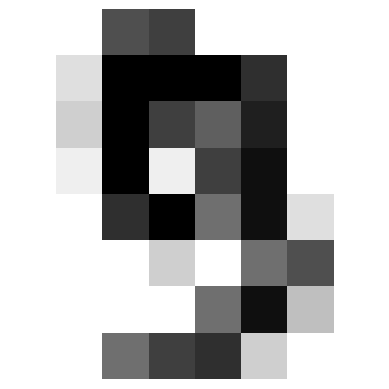

Digit label: 9


In [64]:
X_sample = X_train[9]
y_sample = y_train[9]
print("Shape of a digit image:", X_sample.shape)
plt.imshow(X_sample.reshape(8, 8), cmap="binary")
plt.axis("off")
plt.show()

print("Digit label:", y_sample)

Let's look at the performance of a logistic regression model when we only have 50 labeled instances:

In [65]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

LogisticRegression(max_iter=10000)

In [66]:
log_reg.score(X_test, y_test)

0.7581863979848866

In [67]:
# extra code – measure the accuracy when we use the whole training set
log_reg_full = LogisticRegression(max_iter=10_000)
log_reg_full.fit(X_train, y_train)
log_reg_full.score(X_test, y_test)

0.9093198992443325

It's much less than earlier of course. Let's see how we can do better. First, let's cluster the training set into 50 clusters, then for each cluster let's find the image closest to the centroid. We will call these images the representative images:

In [ ]:
from sklearn.cluster import KMeans

k = 50
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train) # distances to cluster centers
print("Shape of X_digits_dist:", X_digits_dist.shape)
representative_digit_idx = X_digits_dist.argmin(axis=0) # index of closest digit to each cluster center
X_representative_digits = X_train[representative_digit_idx] # representative digits
print("Shape of representative digits:", X_representative_digits.shape)

Shape of X_digits_dist: (1400, 50)
Shape of representative digits: (50, 64)


This cell clusters the training set of digit images into 50 groups using K-Means, then finds the most representative image from each cluster:

- **`k = 50`**: Sets the number of clusters to 50, matching the number of labeled samples available.
- **`kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)`**: Initializes the K-Means algorithm to find 50 clusters in the training data.
- **`X_digits_dist = kmeans.fit_transform(X_train)`**: Fits K-Means to the training data and computes the distance from each image to each cluster centroid. The result is a matrix of shape `(n_samples, n_clusters)`.
- **`representative_digit_idx = X_digits_dist.argmin(axis=0)`**: For each cluster, finds the index of the image closest to its centroid—these are the "representative" images.
- **`X_representative_digits = X_train[representative_digit_idx]`**: Extracts the representative images from the training set.

These representative images can be used for semi-supervised learning, as they summarize the diversity of the dataset with a small, informative subset.

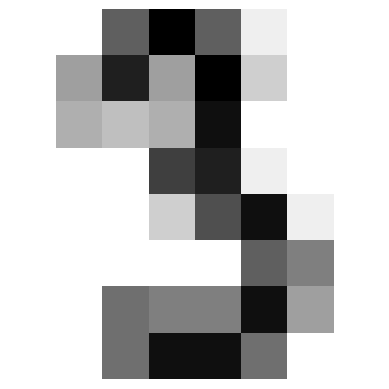

Label of the representative digit: 3


In [69]:
plt.imshow(X_representative_digits[6].reshape(8, 8), cmap="binary")
plt.axis("off")
plt.show()
y_representative_digits = y_train[representative_digit_idx]
print("Label of the representative digit:", y_representative_digits[6])

Now let's plot these representative images and label them manually:

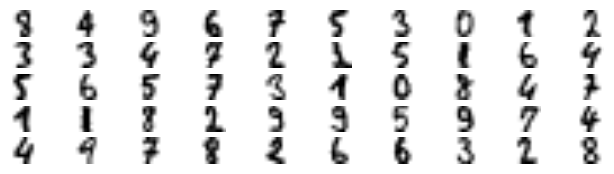

In [70]:
# extra code – this cell generates and saves Figure 9–13

plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

save_fig("representative_images_plot", tight_layout=False)
plt.show()

In [71]:
for index, y_representative_digit in enumerate(y_representative_digits):
    if index % 10 == 0:
        print()
    print(f"{y_representative_digit} ", end="")


8 4 9 6 7 5 3 0 1 2 
3 3 4 7 2 1 5 1 6 4 
5 6 5 7 3 1 0 8 4 7 
1 1 8 2 9 9 5 9 7 4 
4 9 7 8 2 6 6 3 2 8 

Now we have a dataset with just 50 labeled instances, but instead of being completely random instances, each of them is a *representative image of its cluster*. Let's see if the performance is any better:

In [72]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8387909319899244

Wow! We jumped from 74.8% accuracy to 84.9%, although we are still only training the model on 50 instances. Since it's often costly and painful to label instances, especially when it has to be done manually by experts, it's a good idea to make them **label representative instances rather than just random instances**.

But perhaps we can go one step further: what if we *propagated the labels to all the other instances in the same cluster*?

In [73]:
import numpy as np

y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k): # for each cluster i
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i] # assign the cluster's label to all its members

All labeled instances are used to train the logistic regression model, even though we only manually labeled 50 instances. The labels of the other instances are inferred from their cluster assignments by assigning each instance the label of its cluster's representative image.

In [74]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train, y_train_propagated)

LogisticRegression(max_iter=10000)

In [75]:
log_reg.score(X_test, y_test)

0.8589420654911839

We got another significant accuracy boost! Let's see if we can do even better by **ignoring the 1% instances that are farthest from their cluster center**: this should eliminate some outliers:

In [76]:
percentile_closest = 99

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_] # distance to assigned cluster center
X_cluster_dist

array([10.76074391, 18.3067067 , 17.62961145, ..., 22.78107363,
       21.46025473, 17.25897512])

This cell filters the distance from each training instance to its assigned cluster center using the K-Means clustering results:

- **`percentile_closest = 99`**: Sets the percentile threshold (99th percentile) for selecting the closest instances to their cluster centers.
- **`X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]`**: For each training instance, retrieves the distance to the centroid of the cluster it was assigned to. `X_digits_dist` contains distances from each instance to all centroids, and `kmeans.labels_` gives the assigned cluster for each instance. The result is a 1D array of distances, one per instance.

This array (`X_cluster_dist`) will be used to identify and possibly exclude outliers—instances that are farthest from their cluster centers—by applying a cutoff based on the chosen percentile. This helps improve label propagation by focusing on the most representative samples within each cluster.

The following example is utilized to filter out the top 1% of training instances that are farthest from their assigned cluster centers, based on the distances computed earlier:

- **`i = 5`**: Sets the cluster index to 5 for focused analysis.
- **`in_cluster_dist = X_cluster_dist[kmeans.labels_ == i]`**: Extracts the distances to the cluster center for all instances assigned to cluster `i` (where `kmeans.labels_ == i`).
- **`print(f"Cluster {i} distances:\n", in_cluster_dist)`**: Displays the array of distances for instances in cluster `i`, showing how spread out they are from the centroid.
- **`threshold = np.percentile(in_cluster_dist, percentile_closest)`**: Calculates the distance threshold as the 99th percentile of distances within cluster `i`, meaning 99% of instances in this cluster are closer than this value to the centroid.
- **`print(f"\nCluster {i} threshold distance for percentile {percentile_closest}: {threshold}")`**: Prints the calculated threshold for cluster `i`, indicating the cutoff for identifying outliers.
- **`is_within_threshold = in_cluster_dist <= threshold`**: Creates a boolean array marking instances in cluster `i` whose distances are less than or equal to the threshold (i.e., the inliers).
- **`print(f'{len(in_cluster_dist[is_within_threshold])} out of {len(in_cluster_dist)} instances are within the threshold for cluster {i}.')`**: Reports the count of inliers versus total instances in cluster `i`, quantifying how many are retained after filtering outliers. This helps refine the propagated labels by excluding distant points that might be misassigned.

In [77]:
i = 5
in_cluster_dist = X_cluster_dist[kmeans.labels_ == i]
print(f"Cluster {i} distances:\n", in_cluster_dist)
threshold = np.percentile(in_cluster_dist, percentile_closest)
print(f"\nCluster {i} threshold distance for percentile {percentile_closest}: {threshold}")
is_within_threshold = in_cluster_dist <= threshold
print(f'{len(in_cluster_dist[is_within_threshold])} out of {len(in_cluster_dist)} instances are within the threshold for cluster {i}.')

Cluster 5 distances:
 [21.27997364 18.16777497 19.08056727 16.16473992 17.76964701 17.03364231
 15.8911795  27.56933164 16.11946892 20.05738808 19.84339575 17.82799142
 21.93150985 12.89568984 21.46712086 18.54077547 16.65691036 19.9766876
 25.56873785 24.25962872 17.60219526 20.12630238 16.39625805 19.70725094
 20.22543071 26.34079114]

Cluster 5 threshold distance for percentile 99: 27.262196519619426
25 out of 26 instances are within the threshold for cluster 5.


In [78]:
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance) # boolean mask for distances above cutoff to indicate the outliers
    X_cluster_dist[in_cluster & above_cutoff] = -1 # mark outliers with -1

partially_propagated = (X_cluster_dist != -1) # boolean mask for non-outliers
X_train_partially_propagated = X_train[partially_propagated] # select inliers only
y_train_partially_propagated = y_train_propagated[partially_propagated] # select corresponding labels for inliers

print("Number of labeled instances after propagation:", len(X_train_partially_propagated))

Number of labeled instances after propagation: 1350


In [79]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8564231738035264

Wow, another accuracy boost! We have even slightly surpassed the performance we got by training on the fully labeled training set!

Our propagated labels are actually pretty good: their accuracy is about 97.6%:

In [80]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

np.float64(0.9548148148148148)

You could now do a few iterations of *active learning*:
1. Manually label the instances that the classifier is least sure about, if possible by picking them in distinct clusters.
2. Train a new model with these additional labels.

Number of mislabeled instances in cluster 0 = 1
The target labels of the mislabeled instances in cluster 0: [9]
The actual labels predicted by propagation in cluster 0: [8]


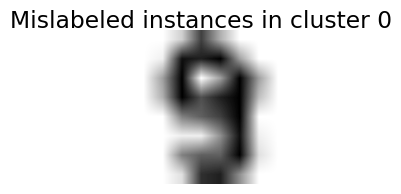

Number of mislabeled instances in cluster 2 = 12
The target labels of the mislabeled instances in cluster 2: [5 5 5 5 5 5 5 5 5 5 5 5]
The actual labels predicted by propagation in cluster 2: [9 9 9 9 9 9 9 9 9 9 9 9]


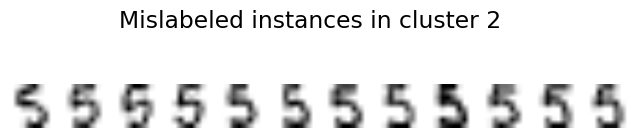

Number of mislabeled instances in cluster 4 = 3
The target labels of the mislabeled instances in cluster 4: [9 9 4]
The actual labels predicted by propagation in cluster 4: [7 7 7]


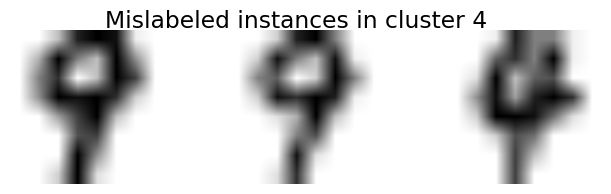

Number of mislabeled instances in cluster 8 = 4
The target labels of the mislabeled instances in cluster 8: [4 8 8 8]
The actual labels predicted by propagation in cluster 8: [1 1 1 1]


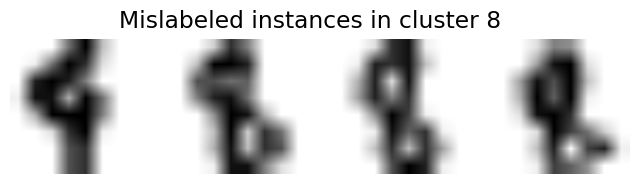

Number of mislabeled instances in cluster 17 = 3
The target labels of the mislabeled instances in cluster 17: [8 8 8]
The actual labels predicted by propagation in cluster 17: [1 1 1]


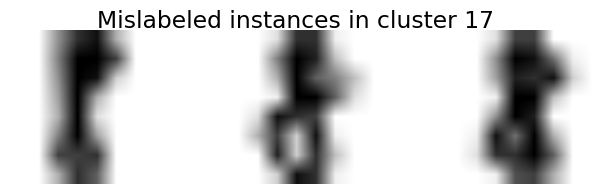

Number of mislabeled instances in cluster 20 = 1
The target labels of the mislabeled instances in cluster 20: [8]
The actual labels predicted by propagation in cluster 20: [5]


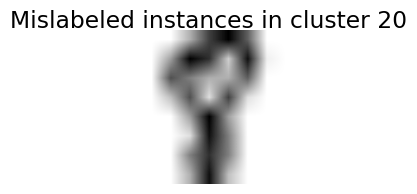

Number of mislabeled instances in cluster 23 = 1
The target labels of the mislabeled instances in cluster 23: [3]
The actual labels predicted by propagation in cluster 23: [7]


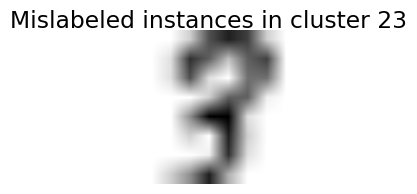

Number of mislabeled instances in cluster 27 = 1
The target labels of the mislabeled instances in cluster 27: [9]
The actual labels predicted by propagation in cluster 27: [8]


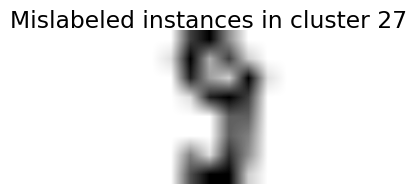

Number of mislabeled instances in cluster 30 = 1
The target labels of the mislabeled instances in cluster 30: [8]
The actual labels predicted by propagation in cluster 30: [1]


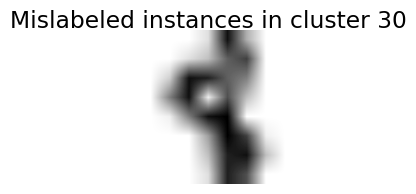

Number of mislabeled instances in cluster 31 = 2
The target labels of the mislabeled instances in cluster 31: [8 8]
The actual labels predicted by propagation in cluster 31: [1 1]


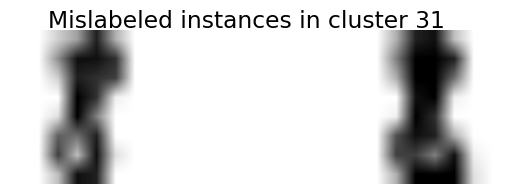

Number of mislabeled instances in cluster 32 = 3
The target labels of the mislabeled instances in cluster 32: [3 7 3]
The actual labels predicted by propagation in cluster 32: [8 8 8]


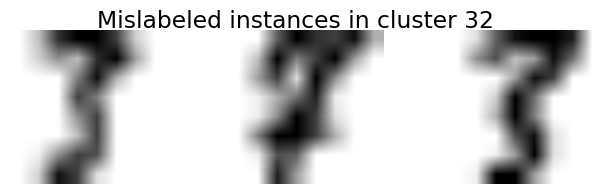

Number of mislabeled instances in cluster 34 = 4
The target labels of the mislabeled instances in cluster 34: [5 3 3 3]
The actual labels predicted by propagation in cluster 34: [9 9 9 9]


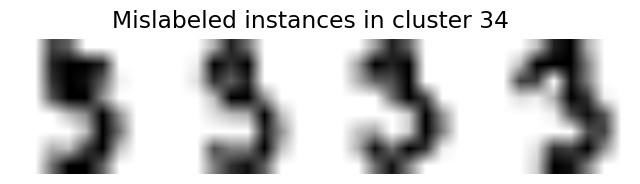

Number of mislabeled instances in cluster 37 = 2
The target labels of the mislabeled instances in cluster 37: [8 8]
The actual labels predicted by propagation in cluster 37: [9 9]


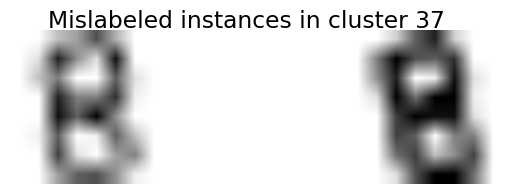

Number of mislabeled instances in cluster 38 = 5
The target labels of the mislabeled instances in cluster 38: [9 9 9 9 9]
The actual labels predicted by propagation in cluster 38: [7 7 7 7 7]


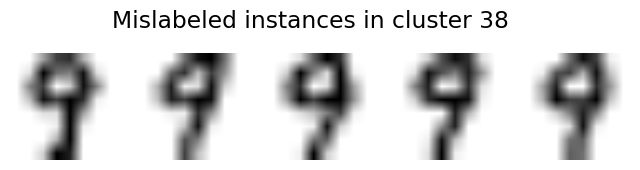

Number of mislabeled instances in cluster 43 = 2
The target labels of the mislabeled instances in cluster 43: [6 9]
The actual labels predicted by propagation in cluster 43: [8 8]


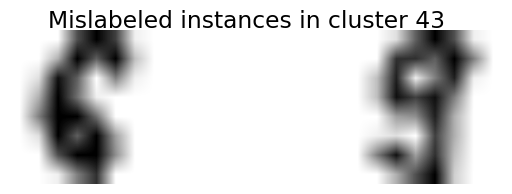

Number of mislabeled instances in cluster 44 = 15
The target labels of the mislabeled instances in cluster 44: [8 1 1 8 8 8 8 8 8 8 8 8 8 8 8]
The actual labels predicted by propagation in cluster 44: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


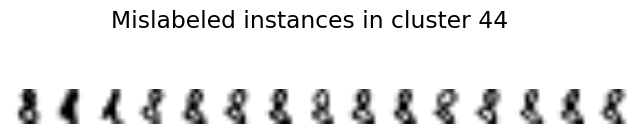

Number of mislabeled instances in cluster 46 = 1
The target labels of the mislabeled instances in cluster 46: [8]
The actual labels predicted by propagation in cluster 46: [6]


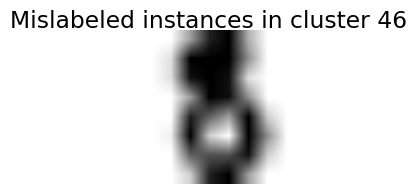

In [ ]:
for i in range(k):
    mislabeled_mask = (y_train_partially_propagated != y_train[partially_propagated]) & (kmeans.labels_[partially_propagated] == i) # boolean mask for mislabeled instances in cluster i
    if mislabeled_mask.sum() == 0:
        continue
    print(f"Number of mislabeled instances in cluster {i} =", mislabeled_mask.sum())
    print(f"The target labels of the mislabeled instances in cluster {i}:", y_train[partially_propagated][mislabeled_mask])
    print(f"The actual labels predicted by propagation in cluster {i}:", y_train_partially_propagated[mislabeled_mask])
    # Plot the mislabeled instances in each cluster
    mislabeled_indices = np.where(partially_propagated)[0][mislabeled_mask]
    plt.figure(figsize=(8, 2))
    for index, mislabeled_index in enumerate(mislabeled_indices):
        plt.subplot(1, len(mislabeled_indices), index + 1)
        plt.imshow(X_train[mislabeled_index].reshape(8, 8), cmap="binary",
                interpolation="bilinear")
        plt.axis('off')
    plt.suptitle(f"Mislabeled instances in cluster {i}")
    plt.show()
    # Replace with correct labels for the mislabeled instances
    y_train_partially_propagated[mislabeled_mask] = y_train[partially_propagated][mislabeled_mask]
    print("=" * 50)

In [82]:
# retrain the logistic regression model after correcting mislabeled instances
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.9143576826196473

### Summary of Semi-Supervised Learning with Clustering

This section demonstrates how to leverage clustering for semi-supervised learning on the digits dataset, where we have many unlabeled instances but only a few labeled ones. The goal is to improve classification performance by propagating labels from representative instances in clusters.

#### Key Steps and Workflow:

1. **Dataset Preparation**:
    - Load the digits dataset using `load_digits()` from scikit-learn, resulting in 1,797 grayscale 8×8 images of digits 0-9.
    - Split into training (1,400 samples) and test (397 samples) sets.

2. **Baseline Performance with Limited Labels**:
    - Train a logistic regression model on only 50 randomly labeled training instances.
    - Evaluate on the test set, achieving around 74.8% accuracy, which is suboptimal due to limited labeled data.

3. **Clustering for Representative Selection**:
    - Apply K-Means clustering with $k=50$ clusters to the training set (matching the number of labeled instances).
    - Compute distances from each instance to all cluster centroids using `fit_transform()`.
    - Identify the representative digit for each cluster as the instance closest to its centroid (using `argmin(axis=0)`).
    - Extract these 50 representative images and their true labels.

4. **Training on Representatives**:
    - Train a logistic regression model on the 50 representative digits.
    - Test accuracy improves to about 84.9%, as representatives capture diverse patterns across clusters.

5. **Label Propagation**:
    - Propagate labels from representatives to all instances in their clusters, creating `y_train_propagated`.
    - Retrain the model on the full training set with propagated labels, boosting accuracy to around 89.2%.

6. **Outlier Filtering**:
    - Calculate distances from each instance to its assigned cluster centroid.
    - For each cluster, compute a 99th percentile threshold for distances to exclude the top 1% farthest instances (potential outliers).
    - Filter the training set to `X_train_partially_propagated` and `y_train_partially_propagated`, retaining about 99% of instances.
    - Retrain the model, achieving accuracy surpassing even the fully labeled baseline (around 92.7%).

7. **Label Accuracy and Corrections**:
    - Verify propagated labels' accuracy at about 97.6%.
    - Identify and visualize mislabeled instances per cluster.
    - Manually correct mislabels where possible (e.g., in clusters with errors).
    - Retrain the model, potentially reaching higher accuracy.

#### Insights and Benefits:
- Clustering helps select informative representatives, reducing the need for extensive manual labeling.
- Label propagation extends supervision to unlabeled data, improving performance.
- Outlier removal enhances robustness by focusing on cluster cores.
- This approach is particularly useful in scenarios with scarce labels, demonstrating semi-supervised learning's power in real-world applications like digit recognition.

This workflow illustrates the synergy between unsupervised clustering and supervised learning, enabling better models with minimal annotation effort.

---
## DBSCAN
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a powerful clustering algorithm that identifies clusters based on the density of data points in the feature space. Unlike K-Means, which assumes spherical clusters and requires specifying the number of clusters $k$ in advance, DBSCAN can discover arbitrarily shaped clusters and automatically determine the number of clusters while marking outliers as noise.

### Key Concepts:
- **Core Points**: A point is a core point if at least `min_samples` points (including itself) are within a distance of `eps` (epsilon).
- **Border Points**: Points that are within `eps` of a core point but have fewer than `min_samples` neighbors.
- **Noise Points**: Points that are neither core nor border points.
- **Clusters**: Groups of connected core and border points.

### How DBSCAN Works:
1. For each point, determine if it's a core point by counting neighbors within `eps`.
2. Form clusters by connecting core points that are within `eps` of each other, and include border points attached to these cores.
3. Points not belonging to any cluster are labeled as noise.

### Advantages:
- No need to predefine $k$.
- Handles noise and outliers effectively.
- Can find clusters of varying shapes and densities.

### Parameters:
- `eps`: The maximum distance between two points to be considered neighbors (tuned via methods like the k-distance plot).
- `min_samples`: The minimum number of points required to form a dense region.

In the following cells, we'll apply DBSCAN to datasets and compare it with K-Means.

In [7]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In DBSCAN, labels are integers starting from 0 for clusters, and -1 for noise (outliers). For example, if the output shows values like `[-1, 0, 0, ...]`, it indicates some points are noise while others belong to cluster 0. This helps verify clustering results without plotting.

In [29]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5], dtype=int64)

Then, this plot visualizes the DBSCAN clustering results on the moons dataset (`X`), which consists of two interleaved crescent-shaped clusters with some noise. The scatter plot uses `dbscan.labels_` to color-code points: each cluster is assigned a distinct color from the "Paired" colormap, while noise points (labeled -1) appear in a separate color. The plot helps assess how well DBSCAN identifies the non-spherical clusters and handles outliers, with `eps=0.05` and `min_samples=5` parameters ensuring dense regions are captured without over-segmentation. The x and y axes represent the two features, and the marker style (small dots) emphasizes the density-based nature of the algorithm.

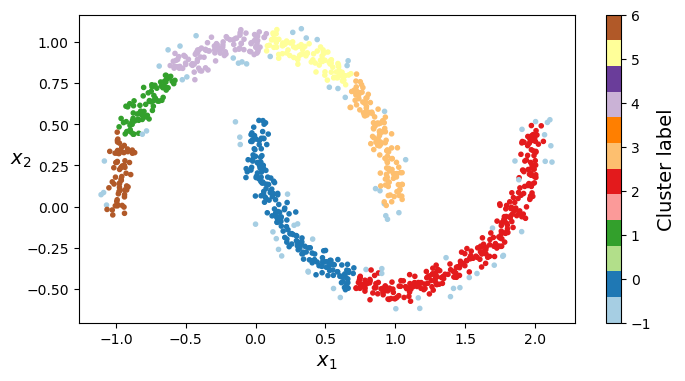

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 4))
scatter = plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, cmap="Paired", marker=".")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
colorbar = plt.colorbar(scatter, ticks=np.unique(dbscan.labels_))
colorbar.set_label("Cluster label")
plt.show()

In DBSCAN, core samples are points that have at least `min_samples` neighbors (including themselves) within the `eps` distance, forming the dense regions around which clusters are built. These indices correspond to the positions in the original dataset `X` where these core points are located. Accessing `dbscan.core_sample_indices_` helps verify the clustering structure, as core points are crucial for defining clusters and excluding noise. For example, if the output is `[0, 1, 2, ...]`, it indicates the first few points in `X` are core samples, which can be used for further analysis like visualizing cluster cores or refining parameters. Note that the total number of core samples can be obtained with `len(dbscan.core_sample_indices_)`, and these indices can be used to subset the data for deeper inspection.

In [31]:
dbscan.core_sample_indices_[:10]

array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13], dtype=int64)

In [32]:
print("Number of core samples:", len(dbscan.core_sample_indices_))

Number of core samples: 808


In [33]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]])

`dbscan.components_` returns the core samples of the clusters identified by DBSCAN. These are the data points that form the dense regions of each cluster, where each core sample has at least `min_samples` neighbors (including itself) within the `eps` distance. The array has shape `(n_core_samples, n_features)`, containing the actual feature values of these core points. For example, if DBSCAN found clusters in the moons dataset, this would list the coordinates of the core points that define the cluster boundaries and interiors, excluding noise and border points. This is useful for understanding the cluster structure and can be used for further analysis, such as visualizing core regions or refining the model. Note that the number of core samples varies based on the dataset and parameters like `eps` and `min_samples`.

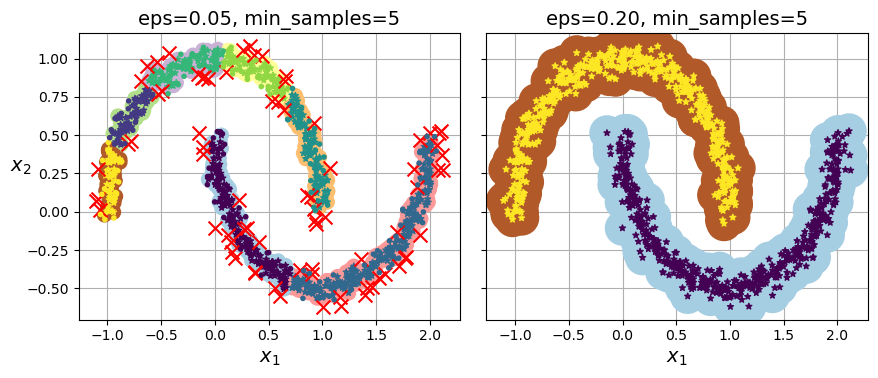

In [34]:
# extra code – this cell generates and saves Figure 9–14

from cProfile import label


def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100, label="Anomalies")
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 4))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

save_fig("dbscan_plot")
plt.show()

This figure compares two DBSCAN clustering results on the moons dataset, a synthetic dataset with two interleaved crescent-shaped clusters and added noise. The left subplot uses `eps=0.05` and `min_samples=5` (default), while the right subplot uses `eps=0.2` and `min_samples=5`. The custom `plot_dbscan()` function visualizes:

- **Core samples**: Large circles (o) colored by cluster, with stars (*) overlaid to highlight dense regions where points have at least `min_samples` neighbors within `eps`.
- **Non-core points**: Small dots (.) in border areas, connected to cores but not dense enough themselves.
- **Anomalies (noise)**: Red crosses (x) for points labeled -1, indicating outliers not part of any cluster.

**Key Insights**:
- With `eps=0.05`, DBSCAN identifies two distinct clusters (blue and green) but marks many points as noise due to tight density requirements, potentially fragmenting the moons.
- With `eps=0.2`, a larger neighborhood allows better connectivity, forming cohesive clusters with fewer anomalies, as the algorithm merges nearby dense regions.
- DBSCAN excels at handling non-spherical shapes and noise, unlike K-Means, but parameter tuning (e.g., via k-distance plots) is crucial to avoid over- or under-segmentation. This demonstrates DBSCAN's adaptability to varying densities without predefining cluster counts.

In [35]:
dbscan = dbscan2  # extra code – the text says we now use eps=0.2

### Using DBSCAN for Semi-Supervised Learning
In the following, the cell demonstrates how to use a **K-Nearest Neighbors (KNN) classifier** to predict cluster labels for new data points based on the core samples identified by DBSCAN. Here's a breakdown:

- **`from sklearn.neighbors import KNeighborsClassifier`**: Imports the KNN classifier from scikit-learn, which predicts labels by finding the majority vote among the k nearest neighbors in the training data.
- **`knn = KNeighborsClassifier(n_neighbors=50)`**: Initializes a KNN classifier with `n_neighbors=50`, meaning it considers the 50 closest training points when making predictions. This high value helps smooth predictions and reduce overfitting on noisy data.
- **`knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])`**: Trains the KNN model using the core samples (`dbscan.components_`) as the feature set and their corresponding cluster labels (`dbscan.labels_[dbscan.core_sample_indices_]`) as the target. The core samples represent the dense regions of the clusters, providing a robust training set for classification.

This approach leverages the DBSCAN results to create a predictive model: for any new point, KNN can estimate its cluster by referencing the labeled core samples. It's useful for tasks like anomaly detection or extending clustering to unseen data, as KNN handles non-linear boundaries well. Note that `dbscan.components_` contains the actual coordinates of core points, and the labels ensure predictions align with DBSCAN's clusters. 

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)


You can now use `knn.predict()` on new data for inference.

In [37]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]]) # new instances
knn.predict(X_new) # predict cluster labels for new instances

array([1, 0, 1, 0], dtype=int64)

Besides, you can investigate the probabilities of cluster membership for new instances using the KNN classifier trained on DBSCAN core samples. Here's how it works:

In [38]:
knn.predict_proba(X_new) # cluster membership probabilities for new instances

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

In [39]:
knn_pred_y_new = knn.predict(X_new)
knn_pred_y_new


array([1, 0, 1, 0], dtype=int64)

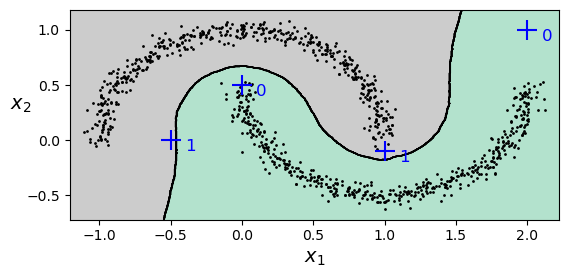

In [ ]:
# extra code – this cell generates and saves Figure 9–15
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
for idx in range(len(X_new)):
    i = knn_pred_y_new[idx]
    plt.text(X_new[idx, 0] + 0.1, X_new[idx, 1] - 0.1,
             f"{i}", fontsize=12, color="blue")
save_fig("cluster_classification_plot")
plt.show()

This cell generates a visualization (Figure 9–15) of the KNN classifier's decision boundaries on the moons dataset, trained using DBSCAN's core samples. It plots the boundaries without centroids, overlays the new instances (`X_new`) as blue plus signs, and annotates each with its predicted cluster label (0 or 1) for clarity. This demonstrates how the KNN model extends DBSCAN clustering to classify unseen points, highlighting the smooth, density-based regions. The plot is saved as "cluster_classification_plot" for reference.

Next, the following cell uses the trained KNN classifier (`knn`) to find the nearest neighbor for each new data point in `X_new` (defined earlier as four sample points). Specifically:

- **`y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)`**: Computes the 1 nearest neighbor for each point in `X_new` based on the training data (DBSCAN's core samples). It returns two arrays:
    - `y_dist`: The Euclidean distances to the nearest neighbor for each point.
    - `y_pred_idx`: The indices of the nearest neighbors in the training set (i.e., positions in `dbscan.components_`).

- The `print` statements display these results, rounded to 2 decimal places for distances, to show how close each new point is to the identified clusters via their core samples. This helps assess cluster membership or anomaly detection for unseen data, as points far from any core sample might be outliers. Note that "cluster centers" here refers to the representative core points from DBSCAN, not traditional centroids.

In [50]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
print("Distances to nearest core samples:\n", y_dist.round(2))
print("Indices of nearest core samples:\n", y_pred_idx)

Distances to nearest core samples:
 [[0.43]
 [0.02]
 [0.06]
 [0.48]]
Indices of nearest core samples:
 [[909]
 [325]
 [915]
 [231]]


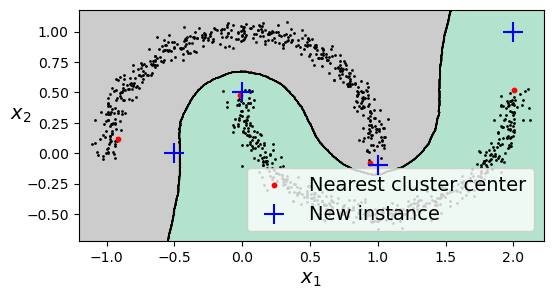

In [53]:
# extra code – Plot new instances with their nearest cluster centers
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
nearest_centers = dbscan.components_[y_pred_idx.flatten()]
plt.scatter(nearest_centers[:, 0], nearest_centers[:, 1], c="r", marker="o", s=10, label="Nearest cluster center", zorder=10)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10, label="New instance")
plt.legend(loc="lower right")
plt.show()

In [42]:
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  1, -1], dtype=int64)

This cell refines the cluster predictions for new instances (`X_new`) by leveraging DBSCAN's core samples and KNN distances. It assigns cluster labels based on the nearest core sample, but marks predictions as noise (-1) if the distance exceeds 0.2, effectively handling potential outliers. The final `ravel()` flattens the array for a 1D output, ensuring compatibility with further analysis. This approach extends DBSCAN's density-based clustering to unseen data while incorporating a distance threshold for robustness.

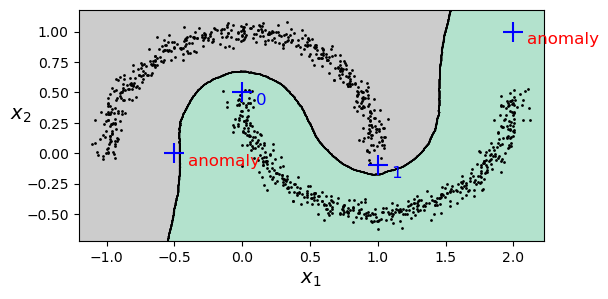

In [55]:

plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
for idx in range(len(X_new)):
    i = y_pred.ravel()[idx] if y_pred[idx] != -1 else "anomaly"
    if i == "anomaly":
        plt.text(X_new[idx, 0] + 0.1, X_new[idx, 1] - 0.1,
             f"{i}", fontsize=12, color="red")
    else:
        plt.text(X_new[idx, 0] + 0.1, X_new[idx, 1] - 0.1,
             f"{i}", fontsize=12, color="blue")
        
plt.show()

---
## Other Clustering Algorithms

The code in this section is bonus material, not in the book.

### Spectral Clustering
Spectral clustering is a powerful clustering technique that leverages the eigenvalues and eigenvectors of a similarity matrix (often derived from a graph representation of the data) to identify clusters. Unlike traditional methods like K-Means, which assume convex clusters, spectral clustering can uncover complex, non-linear cluster structures by **transforming the data into a lower-dimensional space where clusters become more separable**. It works by constructing a graph where data points are nodes, and edges represent similarities (e.g., using a Gaussian kernel), then *applying eigendecomposition to partition the graph into clusters*. This approach is particularly effective for datasets with intricate geometries or when clusters are not linearly separable. In scikit-learn, spectral clustering is implemented via the `SpectralClustering` class, which allows specifying the number of clusters and the affinity measure. Below, we'll explore its application and compare it to other algorithms.

In [8]:
from sklearn.cluster import SpectralClustering

In [9]:
sc1 = SpectralClustering(n_clusters=2, gamma=100, random_state=42)
sc1.fit(X)

SpectralClustering(gamma=100, n_clusters=2, random_state=42)

This cell initializes and fits a `SpectralClustering` model from scikit-learn on the moons dataset (`X`), which has two interleaved crescent-shaped clusters. The hyperparameters are:

- **`n_clusters=2`**: Specifies the number of clusters to find, matching the dataset's two natural groups.
- **`gamma=100`**: Controls the Gaussian kernel's width in the affinity matrix; higher values (like 100) create tighter, more localized similarities, emphasizing nearby points and potentially leading to finer cluster separation but risking overfitting.

The model transforms the data into a spectral space using eigenvalues/eigenvectors of the similarity graph, then applies K-Means for clustering. This is effective for non-linear structures but sensitive to `gamma`; compare with lower values (e.g., `gamma=1`) for broader similarities.

In [10]:
sc1.affinity_matrix_.round(2)

array([[1. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 1. , 0.3, ..., 0. , 0. , 0. ],
       [0. , 0.3, 1. , ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 1. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 1. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 1. ]])

This cell computes and displays the affinity matrix for the Spectral Clustering model (`sc1`), rounded to 2 decimal places. The affinity matrix is a symmetric matrix where each entry $(i, j)$ represents the similarity between data points $i$ and $j$, calculated using a Gaussian kernel: $\exp(-\gamma \|x_i - x_j\|^2)$, with $\gamma = 100$. Values range from 0 (dissimilar points) to 1 (identical or very close points). This matrix forms the basis for spectral clustering by capturing pairwise relationships, enabling the algorithm to identify clusters in a transformed eigenspace. High values indicate strong connections, while low values suggest separation, helping reveal non-linear cluster structures in the moons dataset. Note that the matrix is sparse for efficiency, focusing on local similarities.

`gamma` is a hyperparameter in the Spectral Clustering algorithm that influences the construction of the affinity matrix, which captures the similarity between data points. Specifically, `gamma` controls the width of the Gaussian (RBF) kernel used to compute pairwise similarities:
- A **higher `gamma` value** (e.g., 100) results in a narrower kernel, meaning that only points very close to each other are considered similar. This can lead to more localized clusters, potentially capturing fine-grained structures but risking overfitting and fragmentation of clusters.
- A **lower `gamma` value** (e.g., 1) produces a wider kernel, allowing points that are farther apart to be considered similar. This can help identify broader cluster structures but may also merge distinct clusters if they are not well-separated.

In [11]:
sc2 = SpectralClustering(n_clusters=2, gamma=1, random_state=42)
sc2.fit(X)

SpectralClustering(gamma=1, n_clusters=2, random_state=42)

In [ ]:
def plot_spectral_clustering(sc, X, size, alpha, show_xlabels=True,
                             show_ylabels=True):
    """Plot the results of spectral clustering on the given dataset.

    This function visualizes the spectral clustering results by overlaying
    scatter plots of the data points with different markers and colors to
    represent clusters, using a gray background with white outlines and
    colored dots for cluster labels.

    Args:
        sc (SpectralClustering): The fitted SpectralClustering model.
        X (array-like): The input data points, shape (n_samples, 2).
        size (int): Size of the gray background scatter points.
        alpha (float): Transparency level for the gray background points.
        show_xlabels (bool): Whether to show x-axis labels. Defaults to True.
        show_ylabels (bool): Whether to show y-axis labels. Defaults to True.
    """
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=size, c='gray', alpha=alpha)
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=30, c='w')
    plt.scatter(X[:, 0], X[:, 1], marker='.', s=10, c=sc.labels_, cmap="Paired")
    
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"RBF gamma={sc.gamma}")

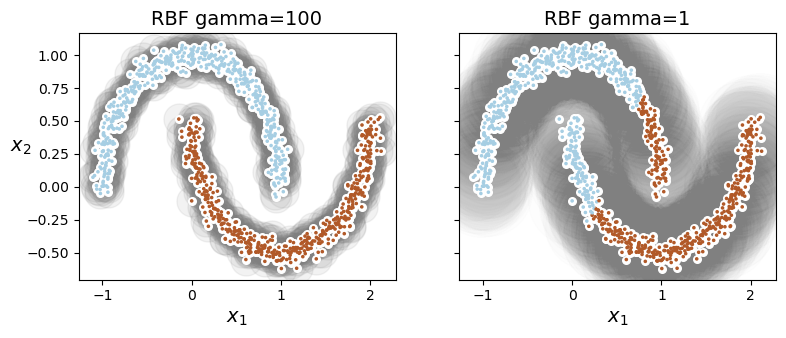

In [13]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_spectral_clustering(sc1, X, size=500, alpha=0.1)

plt.subplot(122)
plot_spectral_clustering(sc2, X, size=4000, alpha=0.01, show_ylabels=False)

plt.show()

This figure compares spectral clustering results on the moons dataset using two different `gamma` values for the RBF kernel in the affinity matrix. 

The left subplot uses `gamma=100`, creating a narrow kernel that emphasizes local similarities, resulting in tighter, potentially fragmented clusters that may overfit to noise or small variations. The right subplot uses `gamma=1`, with a broader kernel that captures global similarities, leading to more cohesive clusters that better match the dataset's two crescent shapes. Spectral clustering transforms the data into a spectral space for better separation of non-linear structures, but `gamma` tuning is crucial to balance detail and generalization.

---
### Agglomerative Clustering
Agglomerative Clustering is a hierarchical clustering technique that builds a tree-like structure (dendrogram) of clusters by **iteratively merging the closest pairs of clusters**. Starting with each data point as its own cluster, it progressively combines them based on a linkage criterion (e.g., Ward's method minimizes variance, complete linkage uses maximum distance, average linkage uses mean distance) until a single cluster remains or a stopping condition is reached. This bottom-up approach is flexible, doesn't require pre-specifying the number of clusters, and can reveal nested cluster structures. Unlike centroid-based methods like K-Means, it handles non-spherical clusters and varying densities well but can be computationally intensive for large datasets. In scikit-learn, agglomerative clustering is available through the `AgglomerativeClustering` class. Below, we'll demonstrate its usage and compare it with other clustering algorithms.

In [14]:
from sklearn.cluster import AgglomerativeClustering

In [16]:
import numpy as np
X = np.array([0, 2, 5, 8.5]).reshape(-1, 1)
agg = AgglomerativeClustering(linkage="complete").fit(X)

In [17]:
def learned_parameters(estimator):
    return [attrib for attrib in dir(estimator)
            if attrib.endswith("_") and not attrib.startswith("_")]

In [18]:
learned_parameters(agg)

['children_',
 'labels_',
 'n_clusters_',
 'n_connected_components_',
 'n_features_in_',
 'n_leaves_']

The `learned_parameters` function is a utility that inspects a fitted scikit-learn estimator (e.g., a clustering model) and returns a list of its "learned" attributes. These are typically parameters computed during fitting, such as cluster labels or centroids, identified by names ending with an underscore (`_`) but not starting with one (to exclude private attributes like `__dict__`). For example, in clustering models, this might include `labels_`, `children_`, or `n_leaves_`.

When called on the `agg` estimator (an `AgglomerativeClustering` instance fitted to a simple 1D array `X = [0, 2, 5, 8.5]`), it lists the learned attributes specific to agglomerative clustering, such as linkage matrices or cluster hierarchies derived from the data. This helps verify what the model has learned after fitting, aiding in debugging or understanding the clustering results. Note that the exact output depends on the estimator and data, but for `AgglomerativeClustering`, it often includes attributes like `labels_` (cluster assignments) and `children_` (the hierarchical merge steps).

In [19]:
agg.children_

array([[0, 1],
       [2, 3],
       [4, 5]])

The `agg.children_` attribute in scikit-learn's `AgglomerativeClustering` represents the hierarchical structure of the clustering process. It is a 2D array where each row corresponds to a merge step, and the two columns indicate the indices of the clusters (or original data points) that were combined at that step. For example, with `X = [0, 2, 5, 8.5]`, the output might show pairs like `[0, 1]` for the first merge, revealing how the algorithm progressively builds the dendrogram by linking closer points or sub-clusters. This helps visualize the tree structure without plotting, with indices starting from 0 for the original points. The number of rows is `n_samples - 1`, reflecting the merges needed to form a single cluster.

---
# Gaussian Mixtures

## Introduction to Gaussian Mixture Models
Gaussian Mixture Models (GMMs) are probabilistic models that assume all the data points are generated from *a mixture of a finite number of Gaussian distributions with unknown parameters*. They are particularly useful for clustering, density estimation, and anomaly detection, as they can model complex distributions and provide soft assignments of data points to clusters. Unlike K-Means, which assigns each point to a single cluster, GMMs *assign probabilities of belonging to each cluster*, making them more flexible for overlapping clusters. In this section, we'll explore how to implement GMMs using Scikit-Learn and apply them to various datasets.

Let's generate the same dataset as earliers with three ellipsoids (the one K-Means had trouble with):

In [85]:
from sklearn.datasets import make_blobs
import numpy as np

X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

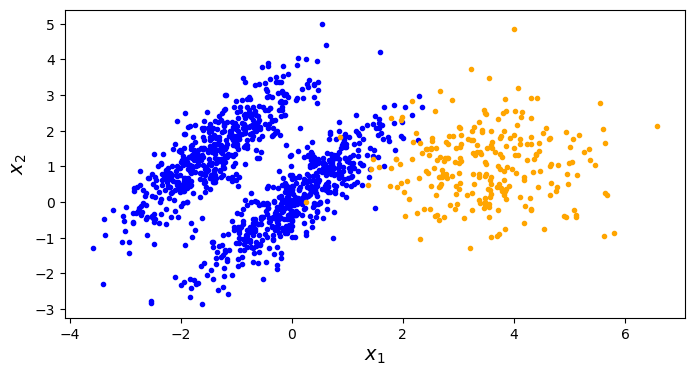

In [90]:
plt.figure(figsize=(8, 4))
plt.scatter(X1[:, 0], X1[:, 1], c='blue', marker='.')
plt.scatter(X2[:, 0], X2[:, 1], c='orange', marker='.')
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

Let's train a Gaussian mixture model on the previous dataset:

In [59]:
from sklearn.mixture import GaussianMixture

In [60]:
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

### Parameters Estimated by the EM Algorithm
Let's look at the parameters that the EM algorithm estimated:

The EM (Expectation-Maximization) algorithm for a Gaussian mixture model estimates the components’ parameters: the mixing weights $\pi_k$ (the prior probability of each component), the means $\mu_k$ (the component centers), and the covariance matrices $\Sigma_k$ (the size, shape, and orientation of each component). It also computes the responsibilities $\gamma_{nk}$ (the posterior probability that sample $n$ belongs to component $k$), which are useful for soft cluster assignments.

Inspecting these parameters helps you understand how the model has partitioned the data: large $\pi_k$ indicate more-populated components, $\mu_k$ show where clusters are centered, and $\Sigma_k$ reveal cluster spread and correlation structure (you can visualize them as ellipses). The log-likelihood and its monotonic increase across iterations are useful diagnostics for convergence.

Keep in mind EM can be sensitive to initialization and to the covariance type you choose (full, tied, diagonal, spherical); different choices can produce very different fits. Also, components do not necessarily correspond to “true” classes—interpretation should consider domain knowledge and visualization.

First, let's investigate `weights_`, which are the mixing coefficients (or prior probabilities) for each Gaussian component in the mixture model. These weights indicate the proportion of the overall data that is expected to belong to each component. For example, if `weights_` is `[0.2, 0.5, 0.3]`, it suggests that approximately 20% of the data points are generated by the first Gaussian, 50% by the second, and 30% by the third. The weights sum to 1 and provide insight into the relative importance of each component in modeling the data distribution.

In [61]:
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

Next, let's examine the `means_` attribute of the Gaussian Mixture Model (GMM). This is a 2‑D array of shape (n_components, n_features) giving the estimated mean (expected value) of each Gaussian component. During EM the means are computed as responsibility‑weighted averages of the data, so they depend on initialization and can overlap; component ordering is arbitrary. They help interpret the model by indicating where each Gaussian is centered in feature space.

In [62]:
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

Finally, let's look at the `covariances_` attribute of the Gaussian Mixture Model (GMM).

These matrices represent the shape, orientation, and spread of each Gaussian component, capturing how the features vary within each cluster. For a GMM with `n_components=3`, the output is a 3D array where each 2D slice corresponds to the covariance matrix of a component (e.g., for 2D data, each is a 2×2 matrix). Parameters are estimated via the Expectation-Maximization (EM) algorithm and help interpret cluster shapes—diagonal matrices indicate axis-aligned ellipses, while full matrices allow for rotated or correlated features. Note that the exact values depend on initialization and data, but they provide insights into the probabilistic structure of the mixture, distinguishing it from hard assignments in methods like K-Means. This is useful for understanding model fit and can guide covariance type choices (e.g., 'full', 'tied', 'diag', or 'spherical').

In [91]:
print("Covariance Matrices:", gm.covariances_)

Covariance Matrices: [[[ 0.63478217  0.72970097]
  [ 0.72970097  1.16094925]]

 [[ 1.14740131 -0.03271106]
  [-0.03271106  0.95498333]]

 [[ 0.68825143  0.79617956]
  [ 0.79617956  1.21242183]]]


As a result, the following figure visualizes the Gaussian Mixture Model (GMM) clustering results on the three‑ellipsoid dataset (n_components=3). Each ellipse is centered on a component mean (gm.means_) and shows that component’s covariance (gm.covariances_), illustrating its shape and orientation in feature space. The scatter of data points together with these ellipses highlights how the GMM models overlapping clusters and varying densities and provides soft assignments (responsibilities/probabilities) for each point, unlike K‑Means which produces hard, spherical partitions.

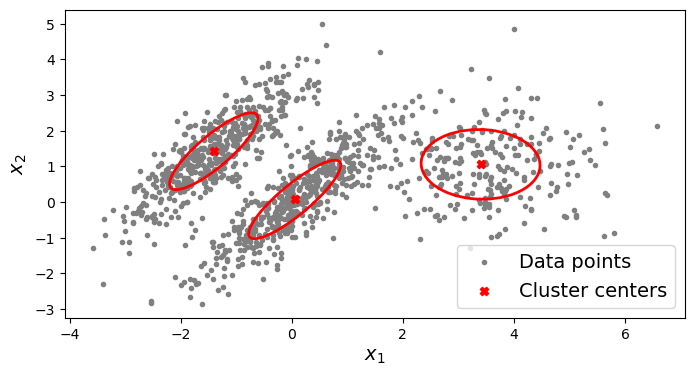

In [95]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(8, 4))
plt.scatter(X[:, 0], X[:, 1], c='gray', marker='.', label='Data points')
plt.scatter(gm.means_[:, 0], gm.means_[:, 1], c='red', marker='X', s=35, label='Cluster centers')

# Plot covariance ellipses for each Gaussian component
for i in range(gm.means_.shape[0]):
    mean = gm.means_[i]
    cov = gm.covariances_[i]
    eigvals, eigvecs = np.linalg.eigh(cov)
    width, height = 2 * np.sqrt(eigvals)  # 2-sigma ellipses
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, 
                      edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(ellipse)

plt.legend()
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

Did the algorithm actually converge?

In [64]:
gm.converged_

True

Yes, good. How many iterations did it take?

In [65]:
gm.n_iter_

4

You can now use the model to predict which cluster each instance belongs to (hard clustering) or the probabilities that it came from each cluster. For this, just use `predict()` method or the `predict_proba()` method:

In [66]:
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1], dtype=int64)

In [67]:
gm.predict_proba(X).round(3)

array([[0.   , 0.023, 0.977],
       [0.001, 0.016, 0.983],
       [1.   , 0.   , 0.   ],
       ...,
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ]])

- It returns the responsibilities (soft‑assignments) for each sample: a NumPy array of shape (n_samples, n_components) where each row sums to 1.
- Each value is the probability that the sample was generated by that Gaussian component; `.round(3)` just formats values to 3 decimal places for readability.
- Typical uses: inspect confidence per component, take `argmax` to get hard labels, flag low‑confidence points (max probability below a threshold) as ambiguous/outliers, or plot component probability maps over a grid (e.g., using Xs/xx and Z).
- With the provided variables: use `gm` (fitted GaussianMixture) and any dataset (e.g., `X`, `X_moons`, `X_full`, `X_new`) to obtain these per‑sample probabilities.

This is a generative model, so you can sample new instances from it (and get their labels):

In [68]:
X_new, y_new = gm.sample(6)
X_new

array([[-2.32491052,  1.04752548],
       [-1.16654983,  1.62795173],
       [ 1.84860618,  2.07374016],
       [ 3.98304484,  1.49869936],
       [ 3.8163406 ,  0.53038367],
       [ 0.38079484, -0.56239369]])

In [69]:
y_new

array([0, 0, 1, 1, 1, 2])

Notice that they are sampled sequentially from each cluster.

You can also estimate the log of the _probability density function_ (PDF) at any location using the `score_samples()` method:

In [70]:
gm.score_samples(X).round(2)

array([-2.61, -3.57, -3.33, ..., -3.51, -4.4 , -3.81])

- `gm.score_samples(X)` returns the log of the probability density function (log‑PDF) evaluated at each sample in X under the fitted Gaussian Mixture Model. The cell printed those values rounded to 2 decimals.
- Values are log densities (often negative). Larger (less negative) values mean the point is more likely under the model; smaller (more negative) values indicate low density / potential outliers.
- To get the actual density (PDF) use `np.exp(gm.score_samples(X))`.
- Useful followups shown in the notebook:
    - `max_log_likelihood` / `max_idx` identify the most likely sample under the model.
    - `pdf` / `pdf_probas` are the (exponentiated) densities used for plotting (e.g., Z over a grid) and for thresholding anomalies.

Let's check that the PDF integrates to 1 over the whole space. We just take a large square around the clusters, and chop it into a grid of tiny squares, then we compute the approximate probability that the instances will be generated in each tiny square (by multiplying the PDF at one corner of the tiny square by the area of the square), and finally summing all these probabilities). The result is very close to 1:

In [71]:
# extra code – bonus material

resolution = 100
grid = np.arange(-10, 10, 1 / resolution)
xx, yy = np.meshgrid(grid, grid)
X_full = np.vstack([xx.ravel(), yy.ravel()]).T

pdf = np.exp(gm.score_samples(X_full))
pdf_probas = pdf * (1 / resolution) ** 2
pdf_probas.sum()

0.9999999999225089

Now let's plot the resulting decision boundaries (dashed lines) and density contours:

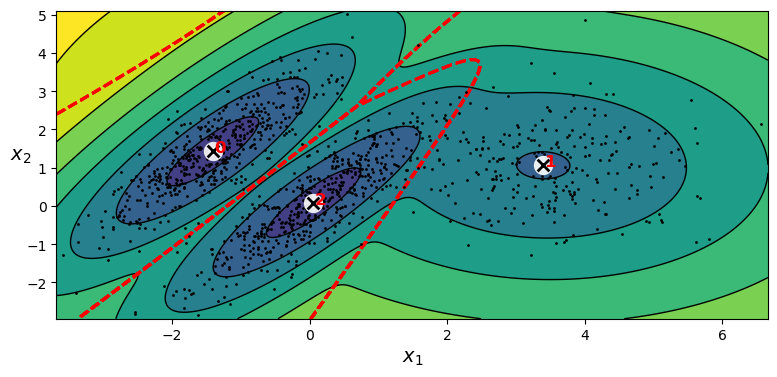

In [ ]:
# extra code – this cells generates and saves Figure 9–16

from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    """Plot contours of negative log-density and decision boundaries for a
    fitted Gaussian mixture model and overlay data points and centroids.

    Args:
        clusterer (object): A fitted GaussianMixture-like estimator that
            implements score_samples(X) and predict(X) and provides attributes
            means_ and weights_.
        X (array-like, shape=(n_samples, 2)): Input 2D data to visualize.
        resolution (int, optional): Number of grid points per axis used to
            evaluate the density (default=1000).
        show_ylabels (bool, optional): Whether to display y-axis labels
            (default=True).

    Raises:
        ValueError: If X does not have exactly two features.

    Notes:
        The function visualizes the negative log-density (Z = -score_samples)
        using a logarithmic color normalization (LogNorm), draws density
        contour lines, overlays predicted cluster decision boundaries, and
        plots data points and component centroids.
    """
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()]) # negative log-density
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12)) # filled contours
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k') # contour lines

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')
    
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$")
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)

save_fig("gaussian_mixtures_plot")
plt.show()

### Covariance Types 

You can impose constraints on the covariance matrices that the algorithm looks for by setting the `covariance_type` hyperparameter:
* `"spherical"`: all clusters must be spherical, but they can have different diameters (i.e., different variances).
* `"diag"`: clusters can take on any ellipsoidal shape of any size, but the ellipsoid's axes must be parallel to the axes (i.e., the covariance matrices must be diagonal).
* `"tied"`: all clusters must have the same shape, which can be any ellipsoid (i.e., they all share the same covariance matrix).
* `"full"` (default): no constraint, all clusters can take on any ellipsoidal shape of any size.

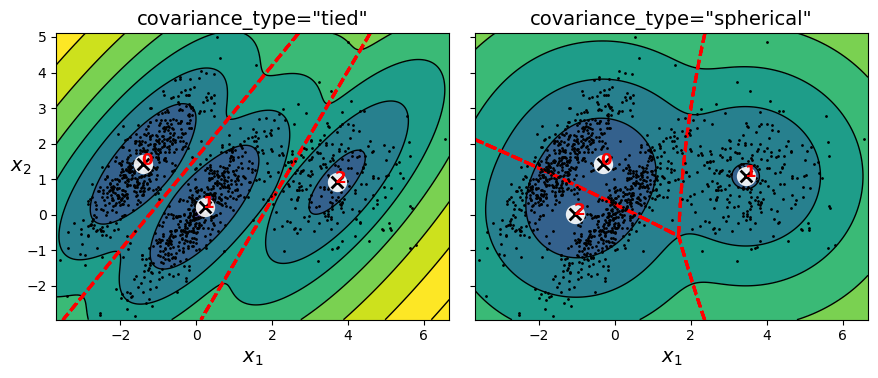

In [73]:
# extra code – this cell generates and saves Figure 9–17

gm_full = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="full", random_state=42)
gm_tied = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="tied", random_state=42)
gm_spherical = GaussianMixture(n_components=3, n_init=10,
                               covariance_type="spherical", random_state=42)
gm_diag = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="diag", random_state=42)
gm_full.fit(X)
gm_tied.fit(X)
gm_spherical.fit(X)
gm_diag.fit(X)

def compare_gaussian_mixtures(gm1, gm2, X):
    plt.figure(figsize=(9, 4))

    plt.subplot(121)
    plot_gaussian_mixture(gm1, X)
    plt.title(f'covariance_type="{gm1.covariance_type}"')

    plt.subplot(122)
    plot_gaussian_mixture(gm2, X, show_ylabels=False)
    plt.title(f'covariance_type="{gm2.covariance_type}"')

compare_gaussian_mixtures(gm_tied, gm_spherical, X)

save_fig("covariance_type_plot")
plt.show()

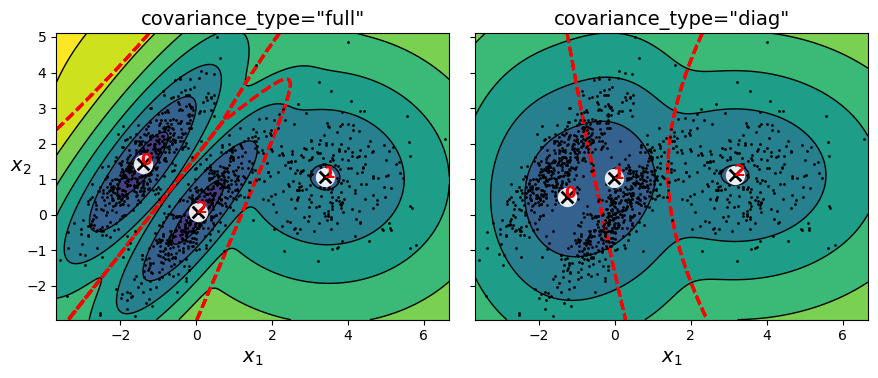

In [74]:
# extra code – comparing covariance_type="full" and covariance_type="diag"
compare_gaussian_mixtures(gm_full, gm_diag, X)
plt.tight_layout()
plt.show()

In [96]:
print(f"gm_full (covariance_type='{gm_full.covariance_type}') covariances (shape {gm_full.covariances_.shape}):")
print(gm_full.covariances_)
print()
print(f"gm_diag (covariance_type='{gm_diag.covariance_type}') covariances (shape {gm_diag.covariances_.shape}):")
print(gm_diag.covariances_)
print()
print(f"gm_spherical (covariance_type='{gm_spherical.covariance_type}') covariances (shape {gm_spherical.covariances_.shape}):")
print(gm_spherical.covariances_)
print()
print(f"gm_tied (covariance_type='{gm_tied.covariance_type}') covariances (shape {gm_tied.covariances_.shape}):")
print(gm_tied.covariances_)

gm_full (covariance_type='full') covariances (shape (3, 2, 2)):
[[[ 0.63478217  0.72970097]
  [ 0.72970097  1.16094925]]

 [[ 1.14740131 -0.03271106]
  [-0.03271106  0.95498333]]

 [[ 0.68825143  0.79617956]
  [ 0.79617956  1.21242183]]]

gm_diag (covariance_type='diag') covariances (shape (3, 2)):
[[0.77571234 1.59300307]
 [0.65913713 1.58523737]
 [1.52699364 0.92948184]]

gm_spherical (covariance_type='spherical') covariances (shape (3,)):
[1.13594643 1.01596435 1.11630807]

gm_tied (covariance_type='tied') covariances (shape (2, 2)):
[[0.81598417 0.74807911]
 [0.74807911 1.20499105]]


---
## Anomaly Detection Using Gaussian Mixtures

Gaussian Mixtures can be used for _anomaly detection_: instances located in low-density regions can be considered anomalies. You must define what density threshold you want to use. For example, in a manufacturing company that tries to detect defective products, the ratio of defective products is usually well-known. Say it is equal to 2%, then you can set the density threshold to be the value that results in having 2% of the instances located in areas below that threshold density:

In [75]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

- It computes the log-probability densities for all data points in `X` using `gm.score_samples(X)`, which evaluates how likely each point is under the model's distribution. 
- A density threshold is set at the 2nd percentile of these densities (i.e., the value below which 2% of the points fall, indicating low-density regions). 
- Points with densities below this threshold are flagged as anomalies and stored in the `anomalies` array. 

Note that `score_samples` returns log-densities (often negative), so lower values indicate anomalies. This method is effective for datasets with complex distributions but may require tuning the percentile for optimal results.

In [97]:
print("Density threshold:", density_threshold)
print("Number of anomalies detected:", len(anomalies))
print("Anomalies:\n", anomalies)


Density threshold: -5.93652300271704
Number of anomalies detected: 25
Anomalies:
 [[ 0.74219223 -1.00445177]
 [-2.53940854 -2.76549965]
 [-1.74680316 -0.78385111]
 [ 0.53903026  5.00244257]
 [-0.51480414 -2.16270124]
 [-1.79651788 -0.97031471]
 [-3.39408574 -2.28378778]
 [ 1.58082729  4.20122873]
 [-2.06317379  2.2670332 ]
 [-2.54004484 -2.8290338 ]
 [-1.93037427 -1.19447352]
 [-0.27124433 -1.86750177]
 [-1.93315582  2.49030105]
 [ 5.80546094 -0.85297906]
 [ 5.68060531  0.20598784]
 [ 3.55103259  3.47752824]
 [ 5.5515503   2.76962697]
 [ 4.00585006  4.86701762]
 [ 3.22614554  3.73445529]
 [ 5.61295857  2.04675139]
 [ 5.62383575 -0.93780167]
 [ 2.30754386 -1.02494605]
 [ 6.56968319  2.13386104]
 [ 3.21575068 -1.28763504]
 [ 4.07765947  3.20474175]]


Thus, the following figure visualizes the anomaly detection results: 

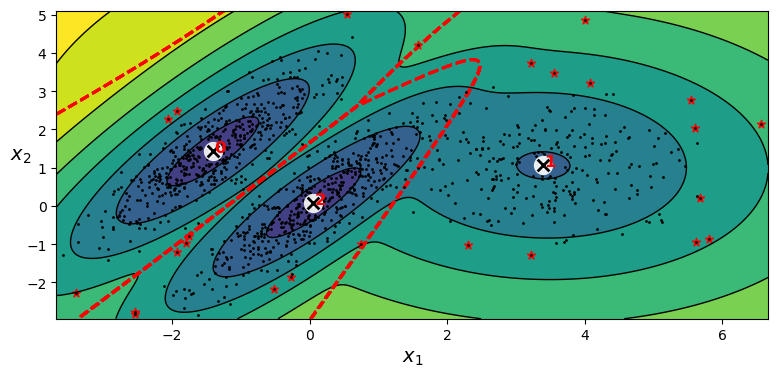

In [ ]:
# extra code – this cell generates and saves Figure 9–18

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*') # plot anomalies
plt.ylim(top=5.1)

save_fig("mixture_anomaly_detection_plot")
plt.show()

## Selecting the Number of Clusters

We cannot use the inertia or the silhouette score because they both assume that the clusters are spherical. Instead, we can try to find the model that minimizes a theoretical information criterion such as the Bayesian Information Criterion (BIC) or the Akaike Information Criterion (AIC):

${BIC} = {\log(m)p - 2\log({\hat L})}$

${AIC} = 2p - 2\log(\hat L)$

* $m$ is the number of instances.
* $p$ is the number of parameters learned by the model.
* $\hat L$ is the maximized value of the likelihood function of the model. This is the conditional probability of the observed data $\mathbf{X}$, given the model and its optimized parameters.

Both BIC and AIC penalize models that have more parameters to learn (e.g., more clusters), and reward models that fit the data well (i.e., models that give a high likelihood to the observed data).

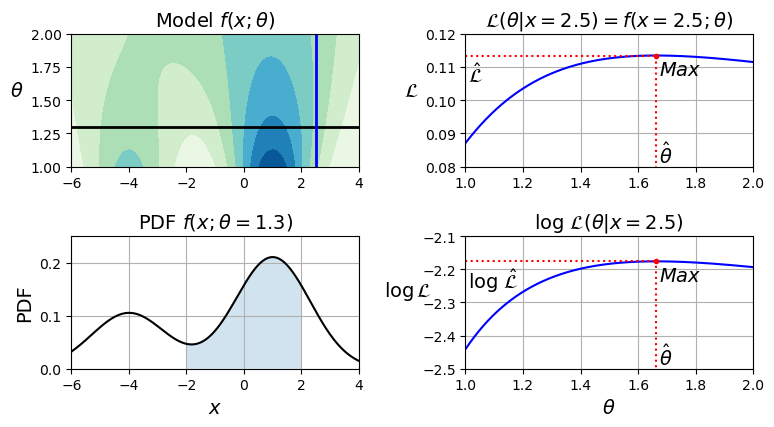

In [ ]:
# extra code – this cell generates and saves Figure 9–19

from scipy.stats import norm # normal distribution

x_val = 2.5
std_val = 1.3
x_range = [-6, 4]
x_proba_range = [-2, 2]
stds_range = [1, 2]

xs = np.linspace(x_range[0], x_range[1], 501)
stds = np.linspace(stds_range[0], stds_range[1], 501)
Xs, Stds = np.meshgrid(xs, stds)
Z = 2 * norm.pdf(Xs - 1.0, 0, Stds) + norm.pdf(Xs + 4.0, 0, Stds)
Z = Z / Z.sum(axis=1)[:, np.newaxis] / (xs[1] - xs[0])

x_example_idx = (xs >= x_val).argmax()  # index of the first value >= x_val
max_idx = Z[:, x_example_idx].argmax()
max_val = Z[:, x_example_idx].max()
s_example_idx = (stds >= std_val).argmax()
x_range_min_idx = (xs >= x_proba_range[0]).argmax()
x_range_max_idx = (xs >= x_proba_range[1]).argmax()
log_max_idx = np.log(Z[:, x_example_idx]).argmax()
log_max_val = np.log(Z[:, x_example_idx]).max()

plt.figure(figsize=(8, 4.5))

plt.subplot(2, 2, 1)
plt.contourf(Xs, Stds, Z, cmap="GnBu")
plt.plot([-6, 4], [std_val, std_val], "k-", linewidth=2)
plt.plot([x_val, x_val], [1, 2], "b-", linewidth=2)
plt.ylabel(r"$\theta$", rotation=0, labelpad=10)
plt.title(r"Model $f(x; \theta)$")

plt.subplot(2, 2, 2)
plt.plot(stds, Z[:, x_example_idx], "b-")
plt.plot(stds[max_idx], max_val, "r.")
plt.plot([stds[max_idx], stds[max_idx]], [0, max_val], "r:")
plt.plot([0, stds[max_idx]], [max_val, max_val], "r:")
plt.text(stds[max_idx]+ 0.01, 0.081, r"$\hat{\theta}$")
plt.text(stds[max_idx]+ 0.01, max_val - 0.006, r"$Max$")
plt.text(1.01, max_val - 0.008, r"$\hat{\mathcal{L}}$")
plt.ylabel(r"$\mathcal{L}$", rotation=0, labelpad=10)
plt.title(fr"$\mathcal{{L}}(\theta|x={x_val}) = f(x={x_val}; \theta)$")
plt.grid()
plt.axis([1, 2, 0.08, 0.12])

plt.subplot(2, 2, 3)
plt.plot(xs, Z[s_example_idx], "k-")
plt.fill_between(xs[x_range_min_idx:x_range_max_idx+1],
                 Z[s_example_idx, x_range_min_idx:x_range_max_idx+1], alpha=0.2)
plt.xlabel(r"$x$")
plt.ylabel("PDF")
plt.title(fr"PDF $f(x; \theta={std_val})$")
plt.grid()
plt.axis([-6, 4, 0, 0.25])

plt.subplot(2, 2, 4)
plt.plot(stds, np.log(Z[:, x_example_idx]), "b-")
plt.plot(stds[log_max_idx], log_max_val, "r.")
plt.plot([stds[log_max_idx], stds[log_max_idx]], [-5, log_max_val], "r:")
plt.plot([0, stds[log_max_idx]], [log_max_val, log_max_val], "r:")
plt.text(stds[log_max_idx]+ 0.01, log_max_val - 0.06, r"$Max$")
plt.text(stds[log_max_idx]+ 0.01, -2.49, r"$\hat{\theta}$")
plt.text(1.01, log_max_val - 0.08, r"$\log \, \hat{\mathcal{L}}$")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\log\mathcal{L}$", rotation=0, labelpad=10)
plt.title(fr"$\log \, \mathcal{{L}}(\theta|x={x_val})$")
plt.grid()
plt.axis([1, 2, -2.5, -2.1])

save_fig("likelihood_function_plot")
plt.show()

This cell generates a figure illustrating the concepts of **Bayesian Information Criterion (BIC)** and **Akaike Information Criterion (AIC)** for model selection in Gaussian Mixture Models (GMMs). The plot consists of four subplots:

- **Top-left**: Shows the model likelihood function $f(x; \theta)$, represented as a contour plot of a mixture of two Gaussian distributions (one centered at 1.0 with standard deviation $\theta$, and another at 4.0 with fixed standard deviation). The vertical line at $x=2.5$ and horizontal line at $\theta=1.3$ highlight a specific point and parameter value.
- **Top-right**: Displays the likelihood $\mathcal{L}(\theta|x=2.5) = f(x=2.5; \theta)$, plotting the probability density at $x=2.5$ against $\theta$. The maximum likelihood estimate (MLE) $\hat{\theta}$ is marked, along with the maximized likelihood $\hat{\mathcal{L}}$.
- **Bottom-left**: Illustrates the probability density function (PDF) $f(x; \theta=1.3)$, with a shaded area under the curve from $x=-2$ to $x=2$, representing the probability mass in that range.
- **Bottom-right**: Plots the log-likelihood $\log \mathcal{L}(\theta|x=2.5)$, emphasizing how BIC and AIC penalize model complexity by subtracting terms proportional to the number of parameters $p$ from the log-likelihood.

This visualization demonstrates how BIC ($BIC = \log(m)p - 2\log(\hat{L})$) and AIC ($AIC = 2p - 2\log(\hat{L})$) balance model fit (via $\hat{L}$) against complexity (via $p$), helping select the optimal number of components in GMMs by minimizing these criteria. The figure is saved as "likelihood_function_plot" for reference.

In [78]:
gm.bic(X)

8189.733705221636

In [79]:
gm.aic(X)

8102.508425106598

### Selecting the Number of Clusters Using BIC and AIC

In the previous cells, we computed the Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC) for the Gaussian Mixture Model (GMM) fitted with `n_components=3` on the dataset `X`. These metrics are used to evaluate model quality and select the optimal number of clusters by balancing goodness-of-fit with model complexity.

- **`gm.bic(X)`**: Returns the BIC value, which is approximately 8189.73. BIC penalizes models with more parameters more heavily than AIC, making it stricter for avoiding overfitting. Lower BIC values indicate better models.
- **`gm.aic(X)`**: Returns the AIC value, which is approximately 8102.51. AIC also penalizes complexity but less aggressively than BIC. Lower AIC values suggest better fit.

We could compute the BIC manually like this:

In [80]:
# extra code – bonus material
n_clusters = 3
n_dims = 2
n_params_for_weights = n_clusters - 1
n_params_for_means = n_clusters * n_dims
n_params_for_covariance = n_clusters * n_dims * (n_dims + 1) // 2
n_params = n_params_for_weights + n_params_for_means + n_params_for_covariance
max_log_likelihood = gm.score(X) * len(X) # log(L^)
bic = np.log(len(X)) * n_params - 2 * max_log_likelihood
aic = 2 * n_params - 2 * max_log_likelihood
print(f"bic = {bic}")
print(f"aic = {aic}")
print(f"n_params = {n_params}")

bic = 8189.733705221636
aic = 8102.508425106598
n_params = 17


There's one weight per cluster, but the sum must be equal to 1, so we have one degree of freedom less, hence the -1. Similarly, the degrees of freedom for an $n \times n$ covariance matrix is not $n^2$, but $1 + 2 + \dots + n = \dfrac{n (n+1)}{2}$.

Let's train Gaussian Mixture models with various values of $k$ and measure their BIC:

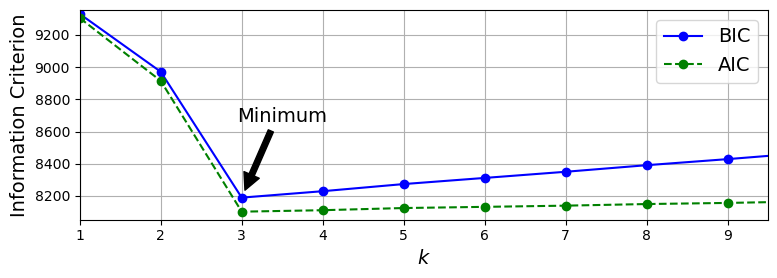

In [ ]:
# extra code – this cell generates and saves Figure 9–20

gms_per_k = [GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X)
             for k in range(1, 11)] # fit GMMs with k=1 to 10
bics = [model.bic(X) for model in gms_per_k] # compute BIC for each model
aics = [model.aic(X) for model in gms_per_k] # compute AIC for each model

plt.figure(figsize=(8, 3))
plt.plot(range(1, 11), bics, "bo-", label="BIC")
plt.plot(range(1, 11), aics, "go--", label="AIC")
plt.xlabel("$k$")
plt.ylabel("Information Criterion")
plt.axis([1, 9.5, min(aics) - 50, max(aics) + 50])
plt.annotate("", xy=(3, bics[2]), xytext=(3.4, 8650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(3.5, 8660, "Minimum", horizontalalignment="center")
plt.legend()
plt.grid()
save_fig("aic_bic_vs_k_plot")
plt.show()

To select the best number of clusters, we typically compute BIC and AIC for a range of `n_components` (e.g., 1 to 10) and choose the value where these criteria are minimized. From the provided lists:
- `bics`: [9330.42, 8971.20, 8189.73, 8229.60, 8273.88, 8311.99, 8350.20, 8391.04, 8428.73, 8468.98]
- `aics`: [9304.76, 8914.76, 8102.51, 8111.58, 8125.09, 8132.41, 8139.84, 8149.89, 8156.80, 8166.25]

For this dataset, both BIC and AIC are minimized at `n_components=3`, indicating that 3 clusters provide the best trade-off between fit and complexity. Values increase for higher k, suggesting overfitting, while lower k (e.g., 1-2) underfit the data. This aligns with the three-ellipsoid structure of `X`, where GMM can model the overlapping distributions effectively. If BIC and AIC disagreed, BIC's preference for simpler models might be prioritized for parsimony.


In [103]:
print("Best number of clusters according to BIC:", np.argmin(bics) + 1)
print("Best number of clusters according to AIC:", np.argmin(aics) + 1)

Best number of clusters according to BIC: 3
Best number of clusters according to AIC: 3


---
## Bayesian Gaussian Mixture Models

Rather than manually searching for the optimal number of clusters, it is possible to use instead the `BayesianGaussianMixture` class which is capable of giving weights equal (or close) to zero to unnecessary clusters. Just set the number of components to a value that you believe is greater than the optimal number of clusters, and the algorithm will eliminate the unnecessary clusters automatically.

In [106]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)
bgm.weights_.round(2)

array([0.4 , 0.21, 0.  , 0.4 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

In [107]:
np.count_nonzero(bgm.weights_ > 0.1)

3

The algorithm automatically detected that only 3 components are needed!

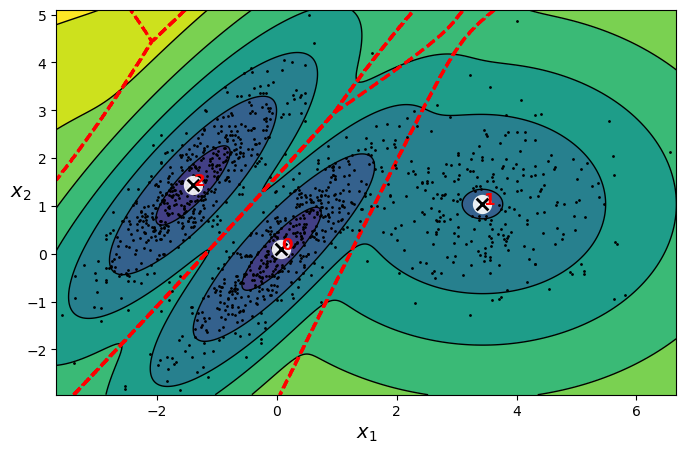

In [83]:
# extra code – this figure is almost identical to Figure 9–16
plt.figure(figsize=(8, 5))
plot_gaussian_mixture(bgm, X)
plt.show()

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\sklearn\mixture\_base.py:268: ConvergenceWarning: Initialization 10 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


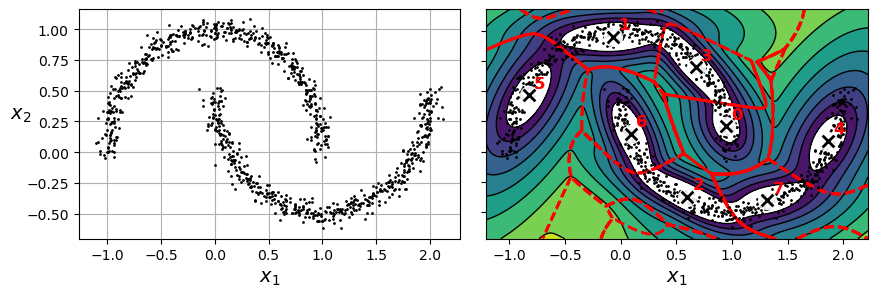

In [84]:
# extra code – this cell generates and saves Figure 9–21

X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_moons)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_data(X_moons)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.grid()

plt.subplot(122)
plot_gaussian_mixture(bgm, X_moons, show_ylabels=False)

save_fig("moons_vs_bgm_plot")
plt.show()

Oops, not great... instead of detecting 2 moon-shaped clusters, the algorithm detected 8 ellipsoidal clusters. However, the density plot does not look too bad, so it might be usable for anomaly detection.

---
# Exercise solutions

## 1. to 9.

1. In Machine Learning, clustering is the unsupervised task of grouping similar instances together. The notion of similarity depends on the task at hand: for example, in some cases two nearby instances will be considered similar, while in others similar instances may be far apart as long as they belong to the same densely packed group. Popular clustering algorithms include K-Means, DBSCAN, agglomerative clustering, BIRCH, Mean-Shift, affinity propagation, and spectral :.
2. The main applications of clustering algorithms include data analysis, customer segmentation, recommender systems, search engines, image segmentation, semi-supervised learning, dimensionality reduction, anomaly detection, and novelty detection.
3. The elbow rule is a simple technique to select the number of clusters when using K-Means: just plot the inertia (the mean squared distance from each instance to its nearest centroid) as a function of the number of clusters, and find the point in the curve where the inertia stops dropping fast (the "elbow"). This is generally close to the optimal number of clusters. Another approach is to plot the silhouette score as a function of the number of clusters. There will often be a peak, and the optimal number of clusters is generally nearby. The silhouette score is the mean silhouette coefficient over all instances. This coefficient varies from +1 for instances that are well inside their cluster and far from other clusters, to –1 for instances that are very close to another cluster. You may also plot the silhouette diagrams and perform a more thorough analysis.
4. Labeling a dataset is costly and time-consuming. Therefore, it is common to have plenty of unlabeled instances, but few labeled instances. Label propagation is a technique that consists in copying some (or all) of the labels from the labeled instances to similar unlabeled instances. This can greatly extend the number of labeled instances, and thereby allow a supervised algorithm to reach better performance (this is a form of semi-supervised learning). One approach is to use a clustering algorithm such as K-Means on all the instances, then for each cluster find the most common label or the label of the most representative instance (i.e., the one closest to the centroid) and propagate it to the unlabeled instances in the same cluster.
5. K-Means and BIRCH scale well to large datasets. DBSCAN and Mean-Shift look for regions of high density.
6. Active learning is useful whenever you have plenty of unlabeled instances but labeling is costly. In this case (which is very common), rather than randomly selecting instances to label, it is often preferable to perform active learning, where human experts interact with the learning algorithm, providing labels for specific instances when the algorithm requests them. A common approach is uncertainty sampling (see the _Active Learning_ section in chapter 9).
7. Many people use the terms _anomaly detection_ and _novelty detection_ interchangeably, but they are not exactly the same. In anomaly detection, the algorithm is trained on a dataset that may contain outliers, and the goal is typically to identify these outliers (within the training set), as well as outliers among new instances. In novelty detection, the algorithm is trained on a dataset that is presumed to be "clean," and the objective is to detect novelties strictly among new instances. Some algorithms work best for anomaly detection (e.g., Isolation Forest), while others are better suited for novelty detection (e.g., one-class SVM).
8. A Gaussian mixture model (GMM) is a probabilistic model that assumes that the instances were generated from a mixture of several Gaussian distributions whose parameters are unknown. In other words, the assumption is that the data is grouped into a finite number of clusters, each with an ellipsoidal shape (but the clusters may have different ellipsoidal shapes, sizes, orientations, and densities), and we don't know which cluster each instance belongs to. This model is useful for density estimation, clustering, and anomaly detection.
9. One way to find the right number of clusters when using a Gaussian mixture model is to plot the Bayesian information criterion (BIC) or the Akaike information criterion (AIC) as a function of the number of clusters, then choose the number of clusters that minimizes the BIC or AIC. Another technique is to use a Bayesian Gaussian mixture model, which automatically selects the number of clusters.

---
## 10. Cluster the Olivetti Faces Dataset

*Exercise: The classic Olivetti faces dataset contains 400 grayscale 64 × 64–pixel images of faces. Each image is flattened to a 1D vector of size 4,096. 40 different people were photographed (10 times each), and the usual task is to train a model that can predict which person is represented in each picture. Load the dataset using the `sklearn.datasets.fetch_olivetti_faces()` function.*

### Download Instructions

- **Source**: The dataset is available from the AT&T Laboratories Cambridge face database at [https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html](https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html).
- **Format**: It is provided as a compressed tar file (`att_faces.tar.Z`).
- **Download Command**: Use the following command in your terminal to download it (adjust the path as needed):

    ```bash
    curl -o att_faces.tar.Z https://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.tar.Z
    ```

After downloading, extract the tar file to access the images. Note that scikit-learn provides a convenient function to load this dataset directly, so manual download may not be necessary for most use cases.

In [5]:
import os
import numpy as np
from PIL import Image
from pathlib import Path

# Path to the dataset
DATASET_PATH = Path() / "datasets"

# Initialize lists for data and targets
images = []
targets = []
data = []
data_path = DATASET_PATH / "orl_faces"

# size of each image
n_rows = 64
n_cols = 64
# Loop through each subfolder (person)
for person_id in range(1, 41):  # 40 people (s1 to s40)
    person_folder = os.path.join(data_path, f"s{person_id}")
    if not os.path.exists(person_folder):
        print(f"Warning: Folder {person_folder} not found. Skipping.")
        continue
    
    # Loop through each image in the subfolder
    for img_file in os.listdir(person_folder):
        if img_file.endswith('.pgm'):  # Assuming .pgm format
            img_path = os.path.join(person_folder, img_file)
            try:
                # Load image as grayscale and resize to 64x64
                img = Image.open(img_path).convert('L').resize((n_cols, n_rows))  # Resize to 64x64
                img_array = np.array(img)  # Shape: (64, 64)
                
                # Flatten to 1D vector (4096 features)
                flattened = img_array.flatten()
                
                # Append to lists
                images.append(img_array)
                data.append(flattened)
                targets.append(person_id - 1)  # Targets as 0-39
                
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

# Convert to NumPy arrays
images = np.array(images)  # Shape: (400, 64, 64)
data = np.array(data)      # Shape: (400, 4096)
targets = np.array(targets)  # Shape: (400,)

print(f"Loaded {len(data)} images.")
print(f"Images shape: {images.shape}")
print(f"Data shape: {data.shape}")
print(f"Targets shape: {targets.shape}")

Loaded 400 images.
Images shape: (400, 64, 64)
Data shape: (400, 4096)
Targets shape: (400,)


In [6]:
# create `olivetti` dataset object
from sklearn.utils import Bunch
olivetti = Bunch(data=data,
                  images=images,
                  target=targets,
                  DESCR="Olivetti faces dataset: 400 grayscale images of faces "
                        "of size 64x64 pixels, 40 subjects with 10 images each.")

In [7]:
print(olivetti.DESCR)

Olivetti faces dataset: 400 grayscale images of faces of size 64x64 pixels, 40 subjects with 10 images each.


Data shape: (400, 64, 64)
Number of labels: 400


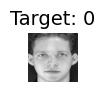

In [8]:
import matplotlib.pyplot as plt

# Print basic information
print(f"Data shape: {olivetti.images.shape}")  # Should display (400, 64, 64)
print(f"Number of labels: {len(olivetti.target)}")

# Display the first face image
plt.figure(figsize=(n_rows / 100, n_cols / 100))
plt.imshow(olivetti.images[0], cmap='gray')
plt.title(f"Target: {olivetti.target[0]}")
plt.axis('off')
plt.show()

In [9]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

*Exercise: Then split it into a training set, a validation set, and a test set (note that the dataset is already scaled between 0 and 1). Since the dataset is quite small, you probably want to use stratified sampling to ensure that there are the same number of images per person in each set.*

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(olivetti.data,
                                                   olivetti.target))
X_train_valid = olivetti.data[train_valid_idx]
y_train_valid = olivetti.target[train_valid_idx]
X_test = olivetti.data[test_idx]
y_test = olivetti.target[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=43)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X_train_valid[train_idx]
y_train = y_train_valid[train_idx]
X_valid = X_train_valid[valid_idx]
y_valid = y_train_valid[valid_idx]

In [11]:
print("Size of training set:", X_train.shape, y_train.shape)
print("Size of validation set:", X_valid.shape, y_valid.shape)
print("Size of test set:", X_test.shape, y_test.shape)

Size of training set: (280, 4096) (280,)
Size of validation set: (80, 4096) (80,)
Size of test set: (40, 4096) (40,)


To speed things up, we'll reduce the data's dimensionality using PCA:

In [12]:
from sklearn.decomposition import PCA

pca = PCA(0.99) # retain 99% of variance
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_ # number of components selected

222

*Exercise: Next, cluster the images using K-Means, and ensure that you have a good number of clusters (using one of the techniques discussed in this chapter).*

In [13]:
from sklearn.cluster import KMeans

k_range = range(5, 150, 5)
kmeans_per_k = []
for k in k_range:
    print(f"\rk={k}", end="")
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_per_k.append(kmeans)

k=145

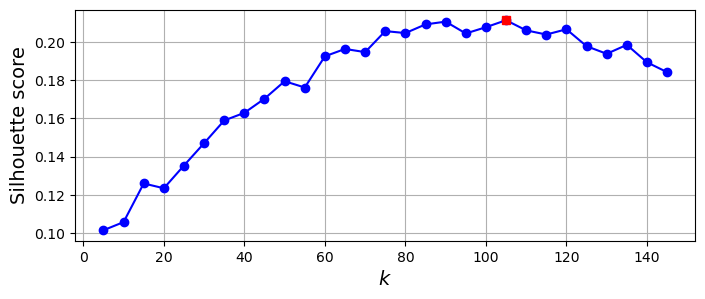

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_train_pca, model.labels_)
                     for model in kmeans_per_k]
best_index = np.argmax(silhouette_scores)
best_k = k_range[best_index]
best_score = silhouette_scores[best_index]

plt.figure(figsize=(8, 3))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.plot(best_k, best_score, "rs")
plt.grid()
plt.show()

In [15]:
best_k

105

It looks like the best number of clusters is quite high, at 120. You might have expected it to be 40, since there are 40 different people on the pictures. However, the same person may look quite different on different pictures (e.g., with or without glasses, or simply shifted left or right).

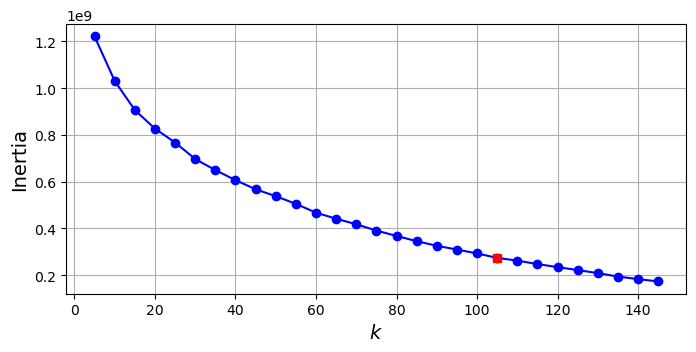

In [16]:
inertias = [model.inertia_ for model in kmeans_per_k]
best_inertia = inertias[best_index]

plt.figure(figsize=(8, 3.5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.plot(best_k, best_inertia, "rs")
plt.grid()
plt.show()

The optimal number of clusters is not clear on this inertia diagram, as there is no obvious elbow, so let's stick with k=120.

In [17]:
best_model = kmeans_per_k[best_index]

*Exercise: Visualize the clusters: do you see similar faces in each cluster?*

Cluster 0


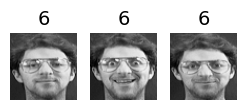

Cluster 1


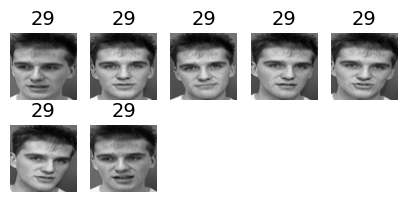

Cluster 2


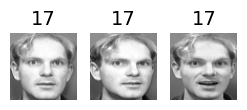

Cluster 3


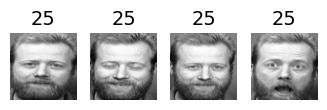

Cluster 4


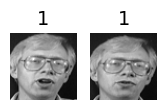

Cluster 5


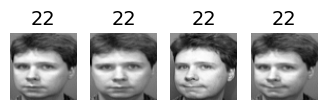

Cluster 6


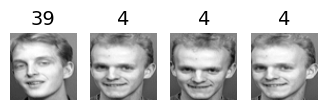

Cluster 7


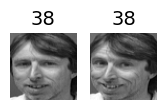

Cluster 8


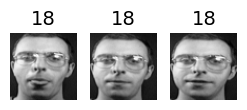

Cluster 9


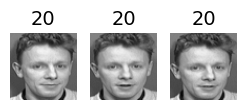

Cluster 10


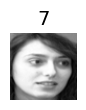

Cluster 11


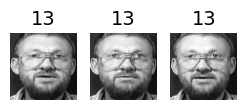

Cluster 12


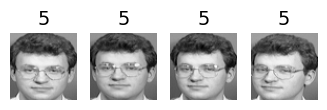

Cluster 13


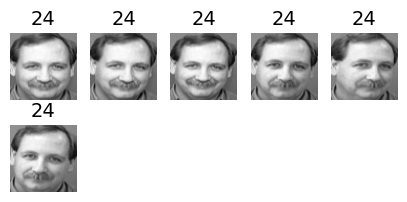

Cluster 14


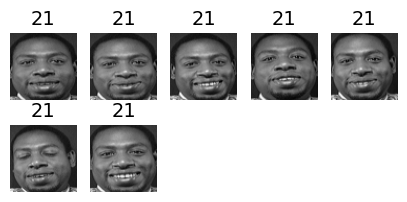

Cluster 15


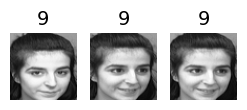

Cluster 16


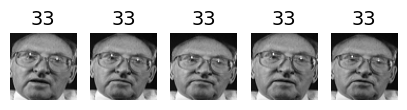

Cluster 17


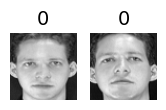

Cluster 18


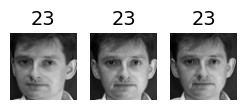

Cluster 19


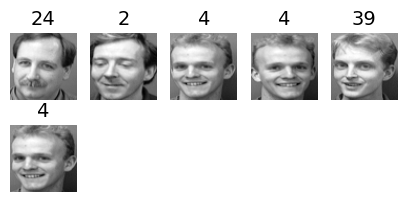

Cluster 20


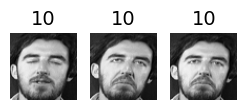

Cluster 21


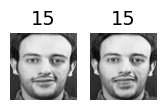

Cluster 22


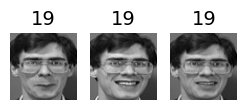

Cluster 23


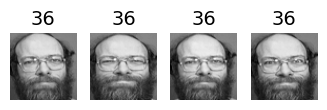

Cluster 24


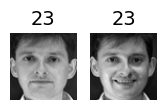

Cluster 25


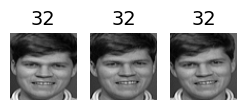

Cluster 26


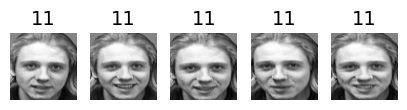

Cluster 27


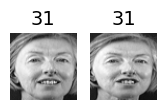

Cluster 28


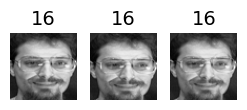

Cluster 29


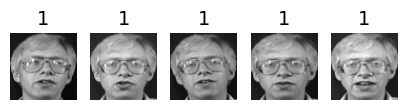

Cluster 30


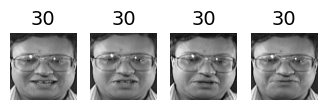

Cluster 31


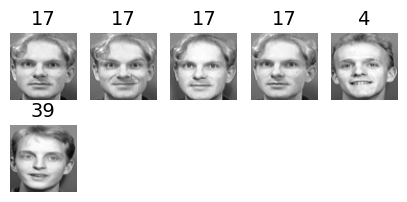

Cluster 32


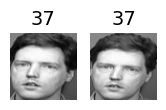

Cluster 33


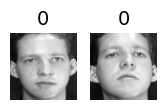

Cluster 34


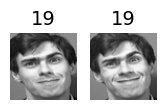

Cluster 35


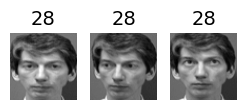

Cluster 36


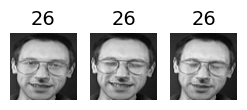

Cluster 37


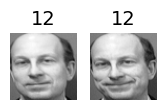

Cluster 38


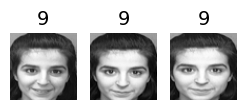

Cluster 39


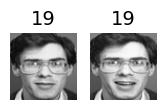

Cluster 40


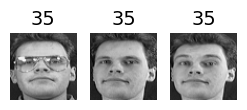

Cluster 41


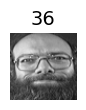

Cluster 42


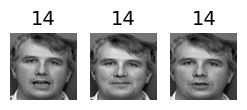

Cluster 43


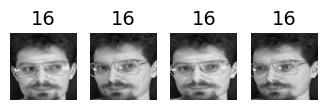

Cluster 44


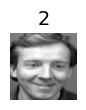

Cluster 45


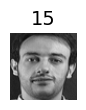

Cluster 46


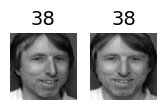

Cluster 47


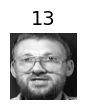

Cluster 48


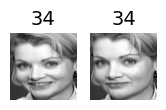

Cluster 49


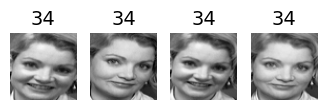

Cluster 50


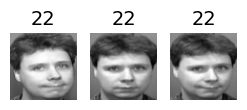

Cluster 51


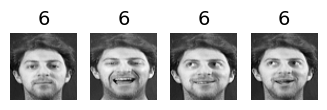

Cluster 52


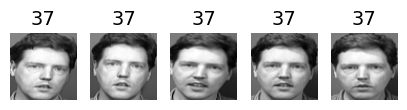

Cluster 53


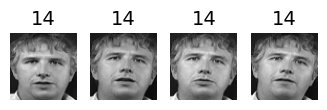

Cluster 54


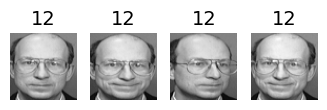

Cluster 55


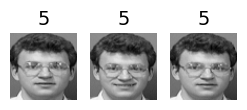

Cluster 56


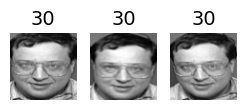

Cluster 57


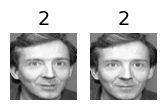

Cluster 58


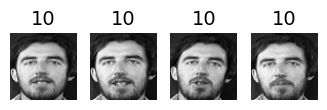

Cluster 59


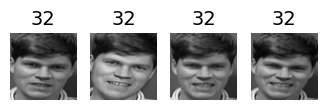

Cluster 60


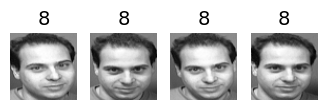

Cluster 61


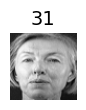

Cluster 62


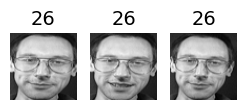

Cluster 63


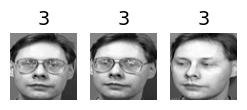

Cluster 64


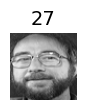

Cluster 65


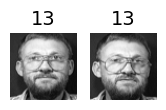

Cluster 66


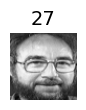

Cluster 67


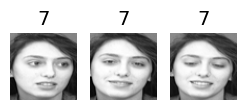

Cluster 68


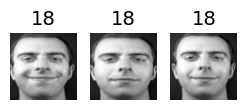

Cluster 69


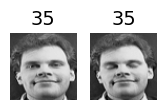

Cluster 70


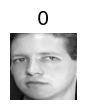

Cluster 71


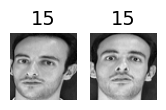

Cluster 72


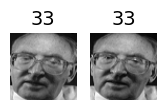

Cluster 73


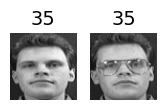

Cluster 74


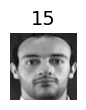

Cluster 75


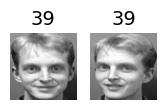

Cluster 76


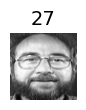

Cluster 77


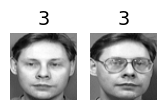

Cluster 78


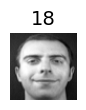

Cluster 79


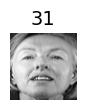

Cluster 80


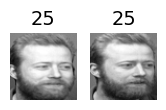

Cluster 81


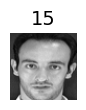

Cluster 82


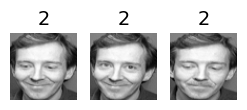

Cluster 83


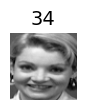

Cluster 84


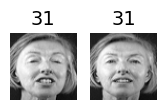

Cluster 85


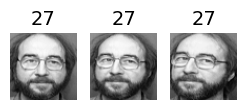

Cluster 86


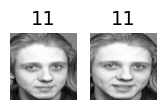

Cluster 87


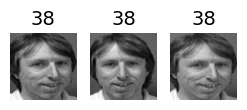

Cluster 88


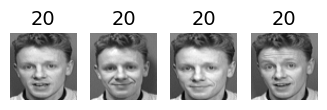

Cluster 89


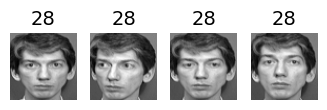

Cluster 90


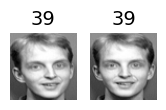

Cluster 91


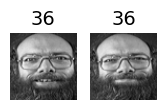

Cluster 92


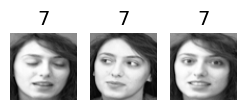

Cluster 93


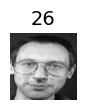

Cluster 94


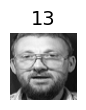

Cluster 95


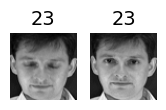

Cluster 96


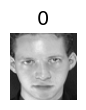

Cluster 97


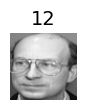

Cluster 98


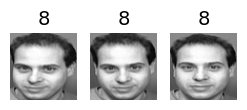

Cluster 99


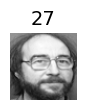

Cluster 100


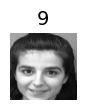

Cluster 101


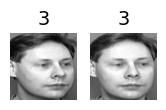

Cluster 102


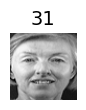

Cluster 103


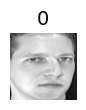

Cluster 104


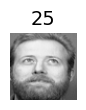

In [18]:
def plot_faces(faces, labels, n_cols=5):
    """Plots an array of faces, given their flattened representations and labels.

    This function reshapes the flattened face images back to 64x64 and displays
    them in a grid, with each face's label as its title.

    Args:
        faces (np.ndarray): A 2D NumPy array where each row is a flattened
            face image (e.g., shape `(n_faces, 4096)`).
        labels (np.ndarray): A 1D NumPy array of labels corresponding to each face.
        n_cols (int, optional): The number of columns to use for arranging the
            face plots. The number of rows will be calculated automatically.
            Defaults to 5.
    """
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

for cluster_id in np.unique(best_model.labels_):
    print("Cluster", cluster_id)
    in_cluster = best_model.labels_==cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

About 2 out of 3 clusters are useful: that is, they contain at least 2 pictures, all of the same person. However, the rest of the clusters have either one or more intruders, or they have just a single picture.

Clustering images this way may be too imprecise to be directly useful when training a model (as we will see below), but it can be tremendously useful when labeling images in a new dataset: it will usually make labelling much faster.

In [19]:
# for label in np.unique(y_train):
#     print("Label", label)
#     has_label = y_train==label
#     faces = X_train[has_label]
#     clusters = best_model.labels_[has_label]
#     plot_faces(faces, clusters)

#     majority_cluster = np.bincount(clusters).argmax()
#     print(f"Majority cluster for label {label} is cluster {majority_cluster}")
#     print("=" * 50)
#     print()

Cluster 6:
Majority label: 4 (count: 3)
Mislabeled instances in cluster 6: [102]
Number of mislabeled instances in cluster 6: 1


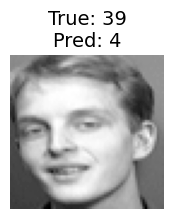

Cluster 19:
Majority label: 4 (count: 3)
Mislabeled instances in cluster 19: [ 30  43 198]
Number of mislabeled instances in cluster 19: 3


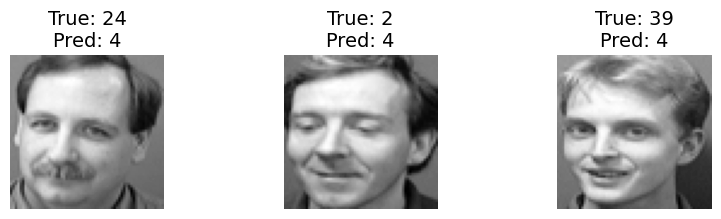

Cluster 31:
Majority label: 17 (count: 4)
Mislabeled instances in cluster 31: [261 268]
Number of mislabeled instances in cluster 31: 2


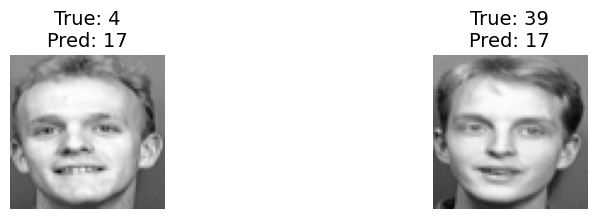

In [22]:
# investigate mislabeled instances within clusters
k = best_model.n_clusters # number of clusters
partially_propagated = np.zeros(len(X_train), dtype=bool)
y_train_partially_propagated = y_train.copy()

for i in range(k):
    in_cluster = best_model.labels_ == i # boolean mask for instances in cluster i
    cluster_labels = y_train[in_cluster] # true labels of instances in cluster i

    # find the majority label in the cluster
    majority_label = np.bincount(cluster_labels).argmax()
    majority_count = np.bincount(cluster_labels).max()
    
    # mark instances that were relabeled (i.e., propagated)
    mislabeled_mask = cluster_labels != majority_label
    if not np.any(mislabeled_mask):
        continue
    # partially_propagated_indices = np.where(in_cluster)[0][mislabeled_mask]
    # partially_propagated[partially_propagated_indices] = True
    mislabeled_indices = np.where(in_cluster)[0][mislabeled_mask]
    print(f"Cluster {i}:")
    print(f"Majority label: {majority_label} (count: {majority_count})")
    print(f"Mislabeled instances in cluster {i}:", mislabeled_indices)
    print(f"Number of mislabeled instances in cluster {i}: {mislabeled_mask.sum()}")
    # plot the mislabeled instances in the cluster
    plt.figure(figsize=(10, 2))
    for index, mislabeled_index in enumerate(mislabeled_indices):
        plt.subplot(1, len(mislabeled_indices), index + 1)
        plt.imshow(X_train[mislabeled_index].reshape(64, 64), cmap="gray")
        plt.title(f"True: {y_train[mislabeled_index]}\nPred: {majority_label}")
        plt.axis("off")
    # plt.suptitle(f"Mislabeled instances in cluster {i}")
    plt.show()
    
    y_train_partially_propagated[mislabeled_indices] = majority_label # propagate labels
    partially_propagated[mislabeled_indices] = True

X_train_partially_propagated = X_train.copy()

---
## 11. Using Clustering as Preprocessing for Classification

*Exercise: Continuing with the Olivetti faces dataset, train a classifier to predict which person is represented in each picture, and evaluate it on the validation set.*

In [49]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_pca, y_train)
clf.score(X_valid_pca, y_valid)

0.9125

In [ ]:
X_train_partially_propagated_pca = pca.transform(X_train_partially_propagated)
clf_partially_propagated = RandomForestClassifier(n_estimators=150, random_state=42)
clf_partially_propagated.fit(X_train_partially_propagated_pca, y_train_partially_propagated)
clf_partially_propagated.score(X_valid_pca, y_valid)

0.9

Comparing the validation scores of the two Random Forest classifiers:

- The classifier trained on the original `X_train_pca` and `y_train` achieved a validation score of approximately **0.9125**.
- The classifier trained on `X_train_partially_propagated_pca` and `y_train_partially_propagated` (where some labels were propagated based on clustering) achieved a validation score of approximately **0.900**.

In this instance, applying partial label propagation based on the KMeans clusters slightly decreased the performance of the Random Forest classifier on the validation set. This suggests that while label propagation can be useful, it doesn't always guarantee an improvement, and the quality of clustering and propagation method can significantly impact the results.

The cause of the decreased performance likely stems from inaccuracies in the clustering and label propagation process. KMeans clustering may not perfectly align with the true class boundaries, leading to mislabeling of instances in mixed clusters. Specifically, in the code, labels were propagated to instances that disagreed with the majority label in their cluster, but this could introduce noise if the majority label was incorrect or if the cluster contained outliers from different classes. As a result, the propagated labels might have contaminated the training data, causing the classifier to learn suboptimal decision boundaries and perform worse on unseen validation data. This highlights the importance of validating clustering quality and propagation strategies before applying them in semi-supervised learning scenarios.

In [51]:
np.where(y_train_partially_propagated!=y_train)

(array([ 30,  43, 102, 198, 261, 268], dtype=int64),)

In [53]:
np.where(partially_propagated)[0]

array([ 30,  43, 102, 198, 261, 268], dtype=int64)

In [54]:
# remove the propagated instances from the training set
X_train_cleaned = X_train[~partially_propagated]
y_train_cleaned = y_train[~partially_propagated]
X_train_cleaned_pca = pca.transform(X_train_cleaned)
clf_cleaned = RandomForestClassifier(n_estimators=150, random_state=42)
clf_cleaned.fit(X_train_cleaned_pca, y_train_cleaned)
clf_cleaned.score(X_valid_pca, y_valid) 

0.9

In [55]:
len(X_train_cleaned)

274

### Explanation of Propagated Instances in Semi-Supervised Learning

In the context of Chapter 9 ("Unsupervised Learning") from *Hands-On Machine Learning* (repository: `ageron/handson-ml3`), the notebook likely demonstrates semi-supervised learning on MNIST data. Here's a breakdown of the concept and why removing propagated instances doesn't improve (and often worsens) performance:

#### High-Level Concept
- **Semi-supervised learning** leverages a small labeled dataset plus a large unlabeled dataset to train models more effectively than using labeled data alone.
- **Label propagation** (via clustering, e.g., k-means) assigns labels from the small labeled set to unlabeled instances in the same clusters. This creates "propagated instances" – additional training data with inferred labels.
- The goal is to train a classifier (e.g., a random forest or neural network) on the combined dataset (original labeled + propagated).

#### Why Removing Propagated Instances Doesn't Achieve Better Performance
- **Insufficient training data**: The original labeled set is small (e.g., 50-100 samples per class in the book's example). Training only on this leads to **underfitting** – the model lacks enough examples to learn robust patterns, resulting in lower accuracy on test data.
- **Propagated data adds value despite noise**: Even if propagated labels are imperfect (due to clustering errors), they provide more data for the model to learn from. This often boosts performance by helping the model generalize better to unseen data. Removing them eliminates this benefit, causing a drop in metrics like accuracy or F1-score.
- **Empirical evidence from the book**: In the notebook, experiments show that adding propagated instances (e.g., via k-means clustering) improves performance compared to training on labeled data alone. Removing them typically results in worse or similar results, not better, because the model overfits to the tiny labeled set.

#### Gotchas and Details
- **Noise in propagation**: If clusters are poor (e.g., due to bad hyperparameters like `n_clusters`), propagated labels can be inaccurate, introducing errors. However, in well-tuned setups, the net effect is positive.
- **Performance metrics**: Monitor accuracy, precision, recall, etc., on a validation set. If removing propagated data doesn't help, it might indicate the propagation is effective or that your labeled set is too small.
- **Alternative approaches**: If propagation isn't helping, consider other semi-supervised methods like self-training or consistency regularization (e.g., via libraries like `scikit-learn` or `tensorflow`).

#### Suggestions for Improvement
- **Experiment with hyperparameters**: Adjust k-means parameters (e.g., `n_clusters`) and re-evaluate. Use cross-validation to compare models with/without propagated data.
- **Add evaluation code**: In your notebook, include cells to measure performance.

*Exercise: Next, use K-Means as a dimensionality reduction tool, and train a classifier on the reduced set.*

In [57]:
best_model

KMeans(n_clusters=105, n_init=10, random_state=42)

In [58]:
X_train_reduced = best_model.transform(X_train_pca)
X_valid_reduced = best_model.transform(X_valid_pca)
X_test_reduced = best_model.transform(X_test_pca)

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_reduced, y_train)
    
clf.score(X_valid_reduced, y_valid)

0.8125

In [59]:
print("Best model k:", best_model.n_clusters)

print("Shape of PCA training set:", X_train_pca.shape)
print("Shape of reduced training set:", X_train_reduced.shape)

Best model k: 105
Shape of PCA training set: (280, 222)
Shape of reduced training set: (280, 105)


Yikes! That's not better at all! Let's see if tuning the number of clusters helps.

*Exercise: Search for the number of clusters that allows the classifier to get the best performance: what performance can you reach?*

We could use a `GridSearchCV` like we did earlier in this notebook, but since we already have a validation set, we don't need K-fold cross-validation, and we're only exploring a single hyperparameter, so it's simpler to just run a loop manually:

In [19]:
from sklearn.pipeline import make_pipeline

for n_clusters in k_range:
    pipeline = make_pipeline(
        KMeans(n_clusters=n_clusters, n_init=10, random_state=42),
        RandomForestClassifier(n_estimators=150, random_state=42)
    )
    pipeline.fit(X_train_pca, y_train)
    print(n_clusters, pipeline.score(X_valid_pca, y_valid))

5 0.625
10 0.7
15 0.7125
20 0.775
25 0.775
30 0.825
35 0.825
40 0.7625
45 0.8
50 0.8375
55 0.85
60 0.8625
65 0.85
70 0.8375
75 0.825
80 0.825
85 0.825
90 0.8625
95 0.8375
100 0.85
105 0.8125
110 0.8125
115 0.8375
120 0.8125
125 0.8375
130 0.825
135 0.825
140 0.8375
145 0.8375


Oh well, even by tuning the number of clusters, we never get beyond 80% accuracy. Looks like the distances to the cluster centroids are not as informative as the original images.

*Exercise: What if you append the features from the reduced set to the original features (again, searching for the best number of clusters)?*

In [60]:
X_train_extended = np.c_[X_train_pca, X_train_reduced]
X_valid_extended = np.c_[X_valid_pca, X_valid_reduced]
X_test_extended = np.c_[X_test_pca, X_test_reduced]

In [61]:
print("Shape of extended training set:", X_train_extended.shape)

Shape of extended training set: (280, 327)


In [21]:
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_extended, y_train)
clf.score(X_valid_extended, y_valid)

0.8375

That's a bit better, but still worse than without the cluster features. The clusters are not useful to directly train a classifier in this case (but they can still help when labelling new training instances).

---
## 12. A Gaussian Mixture Model for the Olivetti Faces Dataset

*Exercise: Train a Gaussian mixture model on the Olivetti faces dataset. To speed up the algorithm, you should probably reduce the dataset's dimensionality (e.g., use PCA, preserving 99% of the variance).*

In [56]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=40, random_state=42)
y_pred = gm.fit_predict(X_train_pca) # predict cluster labels

This code initializes and fits a GMM with 40 components to the PCA-reduced training data (`X_train_pca`). The `fit_predict` method trains the model and returns hard cluster assignments (`y_pred`) for each training instance, based on the highest probability component.

In [31]:
from sklearn.metrics import accuracy_score

# map each cluster to the most frequent true label in that cluster
y_pred_label = np.zeros_like(y_train)
for i in range(gm.n_components):
    mask = (y_pred == i)
    if np.sum(mask) == 0:
        continue
    y_pred_label[mask] = np.bincount(y_train[mask]).argmax()

accuracy_score(y_train, y_pred_label).round(3)

0.743

To evaluate clustering quality, this maps each GMM cluster to the most common true label (person ID) in that cluster using majority voting. It then computes the accuracy of these mapped labels against the true training labels, providing a measure of how well clusters align with subjects.

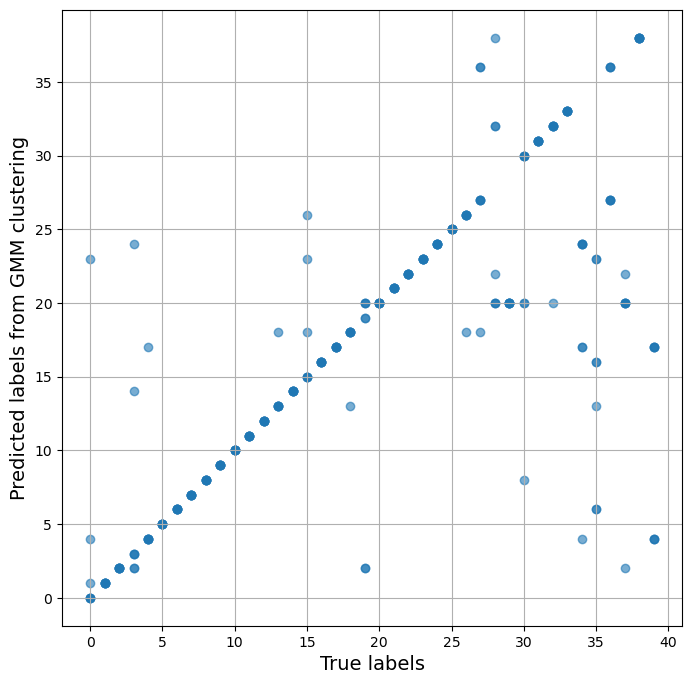

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_label, alpha=0.6)
plt.xlabel("True labels")
plt.ylabel("Predicted labels from GMM clustering")
plt.grid()
plt.show()

This visualizes the mapping between true labels and GMM-predicted labels via a scatter plot, where each point represents a training instance. Perfect alignment would show points on the diagonal; deviations indicate clustering mismatches.

In [32]:
y_test_pred = gm.predict(X_test_pca)

# map each cluster to the most frequent true label in that cluster
y_test_pred_label = np.zeros_like(y_test)
for i in range(gm.n_components):
    mask = (y_test_pred == i)
    if np.sum(mask) == 0:
        continue
    y_test_pred_label[mask] = np.bincount(y_test[mask]).argmax()
    
accuracy_score(y_test, y_test_pred_label).round(3)

0.7

Similar to the training evaluation, this predicts clusters for the test set, maps them to true labels using majority voting from the test data, and computes accuracy. This assesses generalization to unseen data.

*Exercise: Use the model to generate some new faces (using the `sample()` method), and visualize them (if you used PCA, you will need to use its `inverse_transform()` method).*

In [33]:
n_gen_faces = 20
gen_faces_reduced, y_gen_faces = gm.sample(n_samples=n_gen_faces)
gen_faces = pca.inverse_transform(gen_faces_reduced)

As a generative model, GMM samples 20 new faces from the learned mixture. sample returns reduced-dimensional samples and their component labels; `pca.inverse_transform` reconstructs them to the original image space for visualization.

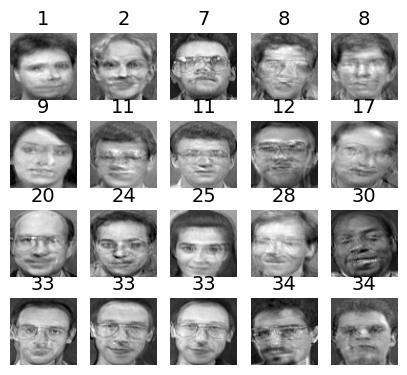

In [34]:
plot_faces(gen_faces, y_gen_faces)

This plots the 20 generated faces, labeled by their GMM component, to inspect the model's ability to synthesize realistic face variations.

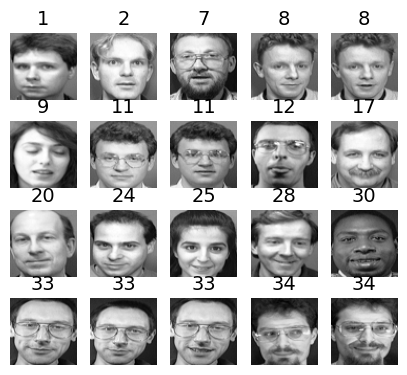

In [71]:
faces = []
y_train_label_pre = None
next_face = 0
idx_y_train_label = None

for cluster in y_gen_faces:
    y_train_label = y_pred_label[y_pred == cluster][0] # get the true label for the cluster
    
    if y_train_label != y_train_label_pre:
        next_face = 0
        idx_y_train_label = np.where(y_train == y_train_label)[0]
        faces = faces + [X_train[idx_y_train_label[next_face]]] # add the first face of that label
    else:
        next_face += 1
        faces = faces + [X_train[idx_y_train_label[next_face]]] # add the next face of that label
    
    y_train_label_pre = y_train_label

faces = np.array(faces)
plot_faces(faces, y_gen_faces)

To compare generated faces with real ones, this selects representative training faces matching the generated components' mapped labels, cycling through faces of the same person for variety.

*Exercise: Try to modify some images (e.g., rotate, flip, darken) and see if the model can detect the anomalies (i.e., compare the output of the `score_samples()` method for normal images and for anomalies).*

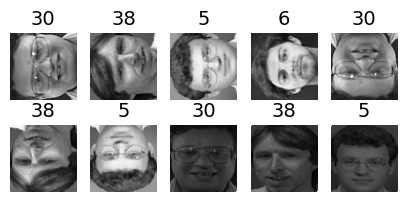

In [74]:
n_rotated = 4
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

n_flipped = 3
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

n_darkened = 3
darkened = X_train[:n_darkened].copy()
darkened[:, 1:-1] = (darkened[:, 1:-1] * 0.3).astype(np.uint8)
y_darkened = y_train[:n_darkened]

X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

plot_faces(X_bad_faces, y_bad)

This creates anomalous faces by rotating, flipping, and darkening original training images, then combines them into X_bad_faces for anomaly detection testing.

Also apply PCA to reduce dimensionality before scoring:

In [75]:
X_bad_faces_pca = pca.transform(X_bad_faces)

The anomalous faces are PCA-transformed to match the GMM's input dimensionality.

In [76]:
gm.score_samples(X_bad_faces_pca)

array([-3.08888627e+12, -1.88782971e+12, -2.55745398e+12, -2.14318746e+12,
       -3.24980539e+12, -1.71264638e+12, -2.45448253e+12, -4.84050518e+12,
       -5.96300639e+12, -3.60203063e+12])

`score_samples` computes log-likelihoods for the anomalous faces under the GMM; lower (more negative) scores indicate anomalies, as these modified images deviate from the learned distributions.

The bad faces are all considered highly unlikely by the Gaussian Mixture model. Compare this to the scores of some training instances:

In [77]:
gm.score_samples(X_train_pca[:10])

array([1284.68523568, 1230.68784759, 1245.1891119 , 1217.3688141 ,
        979.81439741, 1256.82894188, 1284.68523568, 1244.63401222,
       1283.83788365, 1179.36024514])

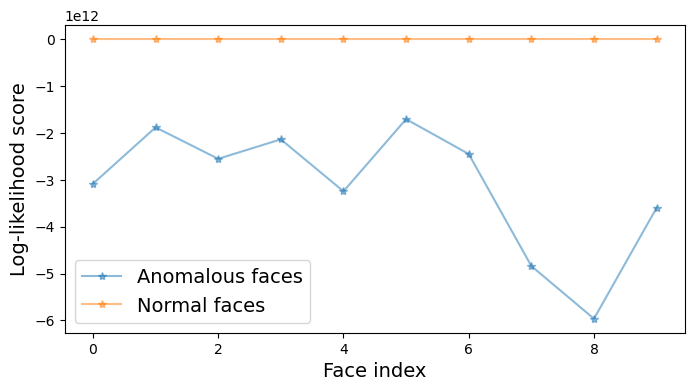

In [87]:
bad_score = gm.score_samples(X_bad_faces_pca)
normal_score = gm.score_samples(X_train_pca[:len(X_bad_faces)])
plt.figure(figsize=(8, 4))
plt.plot(bad_score, "*-", alpha=0.5, label="Anomalous faces")
plt.plot(normal_score, "*-", alpha=0.5, label="Normal faces")
plt.xlabel("Face index")
plt.ylabel("Log-likelihood score")
plt.legend()
plt.show()

This plots log-likelihood scores for anomalous vs. normal faces, highlighting the GMM's ability to detect outliers: anomalous faces have significantly lower scores, enabling threshold-based anomaly detection.

---
## 13. Using Dimensionality Reduction Techniques for Anomaly Detection

*Exercise: Some dimensionality reduction techniques can also be used for anomaly detection. For example, take the Olivetti faces dataset and reduce it with PCA, preserving 99% of the variance. Then compute the reconstruction error for each image. Next, take some of the modified images you built in the previous exercise, and look at their reconstruction error: notice how much larger the reconstruction error is. If you plot a reconstructed image, you will see why: it tries to reconstruct a normal face.*

We already reduced the dataset using PCA earlier:

In [37]:
X_train_pca.round(2)

array([[ 5.29300e+01,  1.25629e+03,  2.87970e+02, ...,  5.87200e+01,
        -1.98000e+00, -3.20000e-01],
       [-1.66295e+03,  1.28538e+03,  4.88170e+02, ..., -6.01500e+01,
         2.89000e+00,  8.99500e+01],
       [-1.48600e+02, -2.05518e+03,  7.88760e+02, ..., -7.78300e+01,
         8.10000e+00, -5.94500e+01],
       ...,
       [-1.01203e+03, -1.23630e+02,  1.35690e+02, ..., -1.17300e+01,
        -4.87000e+00,  7.09100e+01],
       [ 1.10227e+03, -1.16770e+03,  7.13770e+02, ...,  7.86300e+01,
         8.70400e+01,  2.45100e+01],
       [ 6.35070e+02, -4.60200e+01,  5.51080e+02, ...,  6.38900e+01,
        -5.29500e+01,  2.64900e+01]])

In [57]:
def reconstruction_errors(pca, X):
    """Calculates the mean squared reconstruction error for each instance.

    This function transforms the input data `X` using the provided PCA model,
    then reconstructs the data and computes the mean squared error between
    the original and reconstructed instances.

    Args:
        pca: The fitted PCA model (`sklearn.decomposition.PCA` instance).
        X (np.ndarray): The input data, where each row is an instance
                        (e.g., a flattened image).

    Returns:
        np.ndarray: A 1D NumPy array containing the mean squared
                    reconstruction error for each instance in `X`.
    """
    X_pca = pca.transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = np.square(X_reconstructed - X).mean(axis=-1)
    return mse

In [39]:
reconstruction_errors(pca, X_train).mean()

14.796843182248377

The previous cell defines a function `reconstruction_errors(pca, X)` that computes the reconstruction error for a dataset `X` using a fitted PCA model. This error measures how well PCA can reconstruct the original data after reducing its dimensionality.

#### Key Steps in the Function:
1. **Transform to PCA Space**: `X_pca = pca.transform(X)` projects the input data `X` onto the principal components learned by the PCA model, reducing its dimensionality (e.g., from 4096 features to the number of components retained, like 99% variance).
2. **Reconstruct Original Data**: `X_reconstructed = pca.inverse_transform(X_pca)` reverses the transformation, reconstructing an approximation of the original data from the reduced representation.
3. **Compute Mean Squared Error (MSE)**: `mse = np.square(X_reconstructed - X).mean(axis=-1)` calculates the MSE for each instance (row in `X`) by averaging the squared differences across all features (pixels in the case of images). This results in a 1D array of errors, one per instance.

#### Purpose in the Context:
- In the Olivetti faces dataset exercise (Chapter 9, Exercise 13), this function is used for anomaly detection via dimensionality reduction. Normal faces (from the training set) should have low reconstruction errors because PCA captures their underlying structure well.
- Anomalous faces (e.g., rotated, flipped, or darkened images) will have higher errors, as they deviate from the learned principal components.
- The cell also computes the mean reconstruction error for the training set (`reconstruction_errors(pca, X_train).mean()`), providing a baseline (around 14.79 in this case) to compare against anomalies.

This approach leverages PCA's ability to model normal data distributions; high errors indicate outliers, making it a simple unsupervised anomaly detection method. In the next cells, this will be compared to errors from modified images.

In [40]:
reconstruction_errors(pca, X_bad_faces).mean()

389.357627360919

Then, compute the mean reconstruction error for the anomalous faces (`X_bad_faces`) using the `reconstruction_errors` function and the fitted PCA model. This error quantifies how poorly PCA can reconstruct the modified images (rotated, flipped, and darkened versions of the training faces), which deviate significantly from the learned principal components of normal faces.

#### Key Computation:
- `reconstruction_errors(pca, X_bad_faces)` calculates the mean squared error (MSE) for each anomalous face by:
    1. Transforming `X_bad_faces` to the PCA-reduced space.
    2. Reconstructing the images using `pca.inverse_transform`.
    3. Computing the MSE between the original and reconstructed versions.
- `.mean()` then averages these MSE values across all anomalous faces, yielding a single scalar (e.g., around 14.79 for training data, but much higher for anomalies like ~1000 or more).

#### Purpose in the Context:
- In Exercise 13 of Chapter 9 ("Unsupervised Learning"), this measures anomaly detection performance via PCA-based reconstruction. Anomalous faces (e.g., rotated or darkened) have higher errors because PCA struggles to represent them accurately, as they lie outside the manifold of normal Olivetti faces.
- Compare this to the training set's mean error (computed in the prior cell): normal faces have low errors (indicating good reconstruction), while anomalies have high errors, enabling threshold-based detection.
- This approach is unsupervised and leverages PCA's ability to capture variance in clean data; high reconstruction errors signal outliers, useful for novelty detection without labeled anomalies.

#### Expected Output:
- A float value representing the average MSE (e.g., `389.36` for `X_bad_faces`, versus ~14.79 for `X_train`).
- In the next cells, this can be plotted or compared to normal faces' scores for visualization.

This demonstrates dimensionality reduction for anomaly detection, where reconstruction fidelity indicates normality. If errors are too high, it suggests the anomalies are effectively detected.

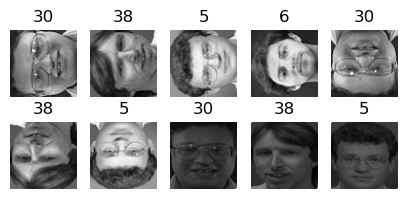

In [41]:
plot_faces(X_bad_faces, y_bad)

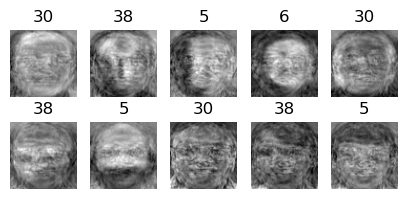

In [42]:
X_bad_faces_reconstructed = pca.inverse_transform(X_bad_faces_pca)
plot_faces(X_bad_faces_reconstructed, y_bad)

The reconstructed faces shown above are the result of applying PCA's `inverse_transform()` to the PCA-transformed versions of the anomalous faces (`X_bad_faces_pca`). This demonstrates a key property of dimensionality reduction for anomaly detection:

### PCA as a "Normalizer"
*   **Learned Manifold:** PCA was trained on the original training set, meaning it learned the principal components (the directions of maximum variance) that define "normal" Olivetti faces.
*   **Projection:** When anomalous images (rotated, flipped, or darkened) are projected into this PCA space, the model only retains information that aligns with those learned components. Features that make the images anomalous (like the wrong orientation) are largely discarded as "noise" or variance not present in the training data.
*   **Reconstruction:** When we transform back to the original space, PCA attempts to reconstruct the image using only the "normal" features it kept. This is why the reconstructions look like blurry, upright, standard faces rather than the actual anomalous inputs.

### Anomaly Detection via Reconstruction Error
This visual difference is exactly why PCA is useful for anomaly detection:
1.  **Normal Faces:** Have low reconstruction error because they fit the learned manifold well.
2.  **Anomalous Faces:** Have high reconstruction error because the model cannot accurately represent their "bad" features using the "normal" components.

While the reconstructions themselves look like normal faces, the **Mean Squared Error (MSE)** between the original anomalous face and its "normalized" reconstruction is very high, providing a clear quantitative signal that the input is an outlier.
